# Clusterização Lca

Notebook para reconstrução da base, preparação da base
do LCA e ajuste do perfil integrado.

In [ ]:
# Configura??o padr?o para figuras vetoriais reprodut?veis
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"


In [101]:
%matplotlib inline

import contextlib
import dataclasses
import json as Json
import pathlib as Pathlib
import re
import time as Time
import types as Types
import unicodedata
import warnings as Warnings

import matplotlib.pyplot as Plot
import numpy as Numpy
import pandas as Pandas
import seaborn as Seaborn
from IPython.display import display as Display
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder
from stepmix.stepmix import StepMix

Pandas.set_option('display.max_columns', 200)
Pandas.set_option('display.max_rows', 120)
Pandas.set_option('display.max_colwidth', 160)
Seaborn.set_theme(style='whitegrid', context='notebook')

REQUIRED_CLEAN_COLUMNS = {
    'data obito',
    'sexo',
    'ocupacao',
    'codigo municipio residencia',
    'causa basica',
}

ORDERED_CLEAN_COLUMNS = [
    'data obito', 'ano obito', 'mes obito', 'dia obito', 'semana obito', 'dia da semana', 'estacao', 'hora obito', 'faixa hora obito',
    'sexo', 'idade', 'faixa etaria', 'raca cor', 'estado civil', 'escolaridade', 'escolaridade do falecido agregada', 'ocupacao', 'ocupacao macro',
    'codigo municipio residencia', 'municipio residencia', 'unidade federativa residencia', 'regiao residencia', 'fonte geografica residencia', 'situacao municipio residencia',
    'codigo municipio ocorrencia', 'municipio ocorrencia', 'unidade federativa ocorrencia', 'regiao ocorrencia', 'fonte geografica ocorrencia', 'situacao municipio ocorrencia', 'deslocamento geografico',
    'local ocorrencia original', 'local ocorrencia cid', 'local ocorrencia consolidado', 'causa basica', 'causa basica cid 3', 'meio lesao autoprovocada', 'grupo meio lesao autoprovocada', 'mecanismo lesao autoprovocada',
    'linha a', 'linha b', 'linha c', 'linha d', 'linha ii', 'numero causas informadas', 'numero causas informadas faixa', 'indicio transtorno mental', 'indicio transtorno por substancias',
    'circunstancia obito', 'circunstancia registrada como suicidio', 'inconsistencia entre circunstancia e causa basica', 'assistencia medica', 'necropsia', 'fonte',
    'alteracao da causa apos investigacao', 'data da investigacao', 'fonte da investigacao', 'impacto da investigacao nas informacoes',
    'dias entre obito e recebimento original', 'dias entre obito e conclusao da investigacao', 'data de conclusao do caso',
]

DATE_COLUMNS = {
    'data obito',
    'data da investigacao',
    'data de conclusao do caso',
}

INT_COLUMNS = {
    'ano obito',
    'mes obito',
    'dia obito',
    'semana obito',
    'idade',
    'numero causas informadas',
    'dias entre obito e recebimento original',
    'dias entre obito e conclusao da investigacao',
}


@dataclasses.dataclass
class ConfiguracaoPipeline:
    BaseDir: Pathlib.Path
    ArquivoBaseParquet: Pathlib.Path | None
    ArquivoBaseCsv: Pathlib.Path | None
    ArquivoCid: Pathlib.Path | None
    ArquivoOcupacoes: Pathlib.Path | None
    DiretorioDetalhes: Pathlib.Path
    TamanhoAmostraGrade: int | None = None
    KMinimo: int = 2
    KMaximo: int = 6
    NumeroInicializacoes: int = 5
    NumeroMaximoIteracoes: int = 250
    SementeAleatoria: int = 42
    ClasseMinimaAlerta: float = 0.03
    LimiteBaixaConfianca: float = 0.60


@dataclasses.dataclass
class EstadoPipeline:
    Configuracao: ConfiguracaoPipeline
    Tempos: list[dict]
    ArquivosSalvos: dict[str, str]


def normalize_name(value):
    text = str(value or '').replace('\xa0', ' ').strip()
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r'[^A-Za-z0-9]+', ' ', text)
    return ' '.join(text.lower().split())


def find_first_file(base_dir, pattern):
    try:
        return next(base_dir.glob(pattern))
    except StopIteration:
        return None


def column_index(base):
    return {normalize_name(column): column for column in base.columns}


def get_column(base_or_index, canonical_name):
    index = base_or_index if isinstance(base_or_index, dict) else column_index(base_or_index)
    return index.get(canonical_name)


def has_clean_structure(base):
    available = set(column_index(base).keys())
    return REQUIRED_CLEAN_COLUMNS.issubset(available)


def ordered_columns(base):
    index = column_index(base)
    preferred = [index[name] for name in ORDERED_CLEAN_COLUMNS if name in index]
    remaining = [column for column in base.columns if column not in preferred]
    return preferred + remaining


def create_config(base_dir=None):
    root = Pathlib.Path(base_dir or Pathlib.Path.cwd()).resolve()
    output_dir = root / 'outputs_lca'
    output_dir.mkdir(parents=True, exist_ok=True)
    return ConfiguracaoPipeline(
        BaseDir=root,
        ArquivoBaseParquet=find_first_file(root, 'Dataset*2010-2024.parquet'),
        ArquivoBaseCsv=find_first_file(root, 'Dataset*2010-2024.csv'),
        ArquivoCid=find_first_file(root, 'CID*.xlsx'),
        ArquivoOcupacoes=root / 'cbo2002-ocupacao.csv',
        DiretorioDetalhes=output_dir,
    )


def create_state(config):
    return EstadoPipeline(Configuracao=config, Tempos=[], ArquivosSalvos={})


@contextlib.contextmanager
def measure_step(state, step_name):
    start = Time.perf_counter()
    print(f'[Inicio] {step_name}')
    try:
        yield
    finally:
        elapsed = Time.perf_counter() - start
        state.Tempos.append(
            {
                'Etapa': step_name,
                'Tempo Segundos': float(elapsed),
                'Tempo Minutos': float(elapsed / 60.0),
            }
        )
        print(f'[Fim] {step_name}: {elapsed:.2f}s')


def register_file(state, path):
    state.ArquivosSalvos[path.name] = str(path)
    return path


def save_csv(state, table, file_name, em_detalhes=False):
    path = state.Configuracao.DiretorioDetalhes / file_name
    table.to_csv(path, index=False, encoding='utf-8-sig')
    return register_file(state, path)


def save_parquet(state, table, file_name, em_detalhes=False):
    path = state.Configuracao.DiretorioDetalhes / file_name
    table.to_parquet(path, index=False)
    return register_file(state, path)


def save_json(state, content, file_name, em_detalhes=False):
    path = state.Configuracao.DiretorioDetalhes / file_name
    with path.open('w', encoding='utf-8') as stream:
        Json.dump(content, stream, ensure_ascii=False, indent=2)
    return register_file(state, path)


def save_markdown_text(state, text, file_name, em_detalhes=False):
    path = state.Configuracao.DiretorioDetalhes / file_name
    path.write_text(text, encoding='utf-8')
    return register_file(state, path)


def load_main_dataset(config):
    if config.ArquivoBaseParquet and config.ArquivoBaseParquet.exists():
        parquet_df = Pandas.read_parquet(config.ArquivoBaseParquet)
        if has_clean_structure(parquet_df):
            return parquet_df
    if config.ArquivoBaseCsv and config.ArquivoBaseCsv.exists():
        csv_df = Pandas.read_csv(config.ArquivoBaseCsv, low_memory=False)
        if has_clean_structure(csv_df):
            return csv_df
        return csv_df
    if config.ArquivoBaseParquet and config.ArquivoBaseParquet.exists():
        return Pandas.read_parquet(config.ArquivoBaseParquet)
    raise FileNotFoundError('Nenhum arquivo Dataset*2010-2024.csv/parquet foi encontrado.')


def load_inputs(config, state):
    with measure_step(state, 'Carga Dos Insumos'):
        base_original = load_main_dataset(config)
    return {
        'BaseOriginal': base_original,
        'ArquivoCid': config.ArquivoCid,
        'ArquivoOcupacoes': config.ArquivoOcupacoes,
    }


def build_ocupacao_macro_table(base_original):
    ocupacao = get_column(base_original, 'ocupacao')
    ocupacao_macro = get_column(base_original, 'ocupacao macro')
    if not ocupacao or not ocupacao_macro:
        return Pandas.DataFrame(columns=['Ocupacao', 'Ocupacao Macro', 'Codigo Cbo', 'Regra De Classificacao'])
    table = (
        base_original[[ocupacao, ocupacao_macro]]
        .drop_duplicates()
        .rename(columns={ocupacao: 'Ocupacao', ocupacao_macro: 'Ocupacao Macro'})
        .sort_values(['Ocupacao Macro', 'Ocupacao'])
        .reset_index(drop=True)
    )
    table['Codigo Cbo'] = Pandas.NA
    table['Regra De Classificacao'] = 'Base Final Ja Consolidada'
    return table[['Ocupacao', 'Ocupacao Macro', 'Codigo Cbo', 'Regra De Classificacao']]


def build_clean_base(config, state, inputs):
    with measure_step(state, 'Reconstrucao Da Base Limpa'):
        clean_base = inputs['BaseOriginal'].copy()
        if not has_clean_structure(clean_base):
            raise KeyError('O notebook espera o Dataset Suicidio 2010-2024 na estrutura final com nomes intuitivos.')
        index = column_index(clean_base)
        for canonical_name in DATE_COLUMNS:
            column = get_column(index, canonical_name)
            if column:
                clean_base[column] = Pandas.to_datetime(clean_base[column], errors='coerce')
        for canonical_name in INT_COLUMNS:
            column = get_column(index, canonical_name)
            if column:
                clean_base[column] = Pandas.to_numeric(clean_base[column], errors='coerce').astype('Int64')
        clean_base = clean_base[ordered_columns(clean_base)].copy()
        ocupacao_macro_table = build_ocupacao_macro_table(clean_base)
        save_parquet(state, clean_base, 'Dataset Limpo Com Nomes Intuitivos.parquet')
        save_csv(state, ocupacao_macro_table, 'Mapeamento Ocupacao Macro.csv')
        return {
            'BaseLimpa': clean_base,
            'TabelaOcupacaoMacro': ocupacao_macro_table,
        }


def build_data_dictionary(config, state, clean_base):
    with measure_step(state, 'Dicionario De Colunas'):
        table = Pandas.DataFrame(
            [
                {
                    'Coluna': column,
                    'Tipo': str(clean_base[column].dtype),
                    'Cardinalidade': int(clean_base[column].nunique(dropna=False)),
                    'Descricao': 'Coluna usada diretamente a partir da versao final do dataset.',
                }
                for column in clean_base.columns
            ]
        )
        save_csv(state, table, 'Dicionario De Colunas.csv')
        return table


def encode_categorical_base(base):
    encoded = Pandas.DataFrame(index=base.index)
    encoders = {}
    for column in base.columns:
        series = base[column].fillna('Ignorado Ou Nao Preenchido').astype(str)
        categories = sorted(series.unique().tolist())
        category_to_code = {category: int(index) for index, category in enumerate(categories)}
        code_to_category = {str(index): category for category, index in category_to_code.items()}
        encoded[column] = series.map(category_to_code).astype(int)
        encoders[column] = {
            'Categoria Para Codigo': category_to_code,
            'Codigo Para Categoria': code_to_category,
        }
    return encoded, encoders


def extract_class_sizes(posteriors):
    hard_classes = Numpy.asarray(posteriors).argmax(axis=1)
    counts = Pandas.Series(hard_classes).value_counts().sort_index().reindex(range(posteriors.shape[1]), fill_value=0)
    percentages = (counts / counts.sum()).to_dict()
    return (
        hard_classes,
        {str(key): int(value) for key, value in counts.to_dict().items()},
        {str(key): float(value) for key, value in percentages.items()},
        float(counts.min() / counts.sum()),
        float(counts.max() / counts.sum()),
    )


def fit_lca_model(config, matrix, k):
    model = StepMix(
        n_components=k,
        n_steps=1,
        measurement='categorical',
        init_params='random',
        random_state=config.SementeAleatoria,
        n_init=config.NumeroInicializacoes,
        max_iter=config.NumeroMaximoIteracoes,
        verbose=0,
        progress_bar=0,
    )
    model.fit(matrix)
    posteriors = model.predict_proba(matrix)
    _, abs_sizes, pct_sizes, min_class, max_class = extract_class_sizes(posteriors)
    max_posterior = posteriors.max(axis=1)
    metrics = {
        'K': int(k),
        'Observações': int(matrix.shape[0]),
        'Indicadores': int(matrix.shape[1]),
        'Aic': float(model.aic(matrix)),
        'Bic': float(model.bic(matrix)),
        'Sabic': float(model.sabic(matrix)),
        'Relative Entropy': float(model.relative_entropy(matrix)),
        'Mean Max Posterior': float(Numpy.mean(max_posterior)),
        'Min Class Pct': float(min_class),
        'Max Class Pct': float(max_class),
        'Número De Parâmetros': int(model.n_parameters),
        'Converged': bool(getattr(model, 'converged_', False)),
        'Número De Iterações': int(getattr(model, 'n_iter_', -1)),
        'Tamanhos Absolutos': Json.dumps(abs_sizes, ensure_ascii=False),
        'Tamanhos Percentuais': Json.dumps(pct_sizes, ensure_ascii=False),
    }
    return model, posteriors, metrics


Pipeline = Types.SimpleNamespace(
    CriarConfiguracao=create_config,
    CriarEstado=create_state,
    CarregarInsumos=load_inputs,
    MedirEtapa=measure_step,
    ConstruirBaseLimpa=build_clean_base,
    ConstruirDicionarioDeColunas=build_data_dictionary,
    CodificarBaseCategorica=encode_categorical_base,
    AjustarModeloLca=fit_lca_model,
    SalvarCsv=save_csv,
    SalvarParquet=save_parquet,
    SalvarJson=save_json,
    SalvarMarkdownTexto=save_markdown_text,
)

## Configuração E Carga Dos Dados

O notebook usa como insumos a base principal e a planilha de CID. Os nomes das
variáveis internas seguem PascalCase, e as colunas finais ficam em português com
acentuação correta.

In [102]:
Configuracao = Pipeline.CriarConfiguracao()
Estado = Pipeline.CriarEstado(Configuracao)

ClasseMinimaAceitavel = 0.03
LimiteLinhasBaseCompleta = None
ForcarBaseCompletaFinal = True
AmostraProjecao = 200000
TopCategoriasPorClasse = 5

Configuracao.TamanhoAmostraGrade = None
Configuracao.KMinimo = 2
Configuracao.KMaximo = 6
Configuracao.NumeroInicializacoes = 5
Configuracao.NumeroMaximoIteracoes = 250
Configuracao.ClasseMinimaAlerta = ClasseMinimaAceitavel

Insumos = Pipeline.CarregarInsumos(Configuracao, Estado)

TabelaConfiguracao = Pandas.DataFrame(
    [
        {'Par\u00e2metro': 'Arquivo Base Parquet', 'Valor': str(Configuracao.ArquivoBaseParquet)},
        {'Par\u00e2metro': 'Arquivo Base Csv', 'Valor': str(Configuracao.ArquivoBaseCsv)},
        {'Par\u00e2metro': 'Arquivo Cid', 'Valor': str(Configuracao.ArquivoCid)},
        {'Par\u00e2metro': 'Arquivo Ocupacoes', 'Valor': str(Configuracao.ArquivoOcupacoes)},
        {'Par\u00e2metro': 'Diretorio De Saidas', 'Valor': str(Configuracao.DiretorioDetalhes)},
        {'Par\u00e2metro': 'Tamanho Amostra Grade', 'Valor': 'Base Completa' if Configuracao.TamanhoAmostraGrade is None else Configuracao.TamanhoAmostraGrade},
        {'Par\u00e2metro': 'K Inicial', 'Valor': Configuracao.KMinimo},
        {'Par\u00e2metro': 'K Final', 'Valor': Configuracao.KMaximo},
        {'Par\u00e2metro': 'Numero Inicializacoes', 'Valor': Configuracao.NumeroInicializacoes},
        {'Par\u00e2metro': 'Maximo Iteracoes', 'Valor': Configuracao.NumeroMaximoIteracoes},
        {'Par\u00e2metro': 'Classe Minima Aceitavel', 'Valor': ClasseMinimaAceitavel},
        {'Par\u00e2metro': 'Limite Linhas Base Completa', 'Valor': 'Sem Limite (Base Completa)' if LimiteLinhasBaseCompleta is None else LimiteLinhasBaseCompleta},
        {'Par\u00e2metro': 'Forcar Base Completa Final', 'Valor': ForcarBaseCompletaFinal},
        {'Par\u00e2metro': 'Amostra Projecao 2D', 'Valor': AmostraProjecao},
        {'Par\u00e2metro': 'Diretorio De Trabalho', 'Valor': str(Configuracao.BaseDir)},
    ]
)

Display(TabelaConfiguracao)
print('Base Original:', Insumos['BaseOriginal'].shape)

[Inicio] Carga Dos Insumos
[Fim] Carga Dos Insumos: 2.71s


,Parâmetro,Valor
0,Arquivo Base Parquet,C:\Users\anami\Downloads\TCC Aninha\Dataset Suicídio 2010-2024.parquet
1,Arquivo Base Csv,C:\Users\anami\Downloads\TCC Aninha\Dataset Suicídio 2010-2024.csv
2,Arquivo Cid,C:\Users\anami\Downloads\TCC Aninha\CID (1).xlsx
3,Arquivo Ocupacoes,C:\Users\anami\Downloads\TCC Aninha\cbo2002-ocupacao.csv
4,Diretorio De Saidas,C:\Users\anami\Downloads\TCC Aninha\outputs_lca
5,Tamanho Amostra Grade,Base Completa
6,K Inicial,2
7,K Final,6
8,Numero Inicializacoes,5
9,Maximo Iteracoes,250


Base Original: (191025, 61)


## Renomeação, Padronização E Variáveis Derivadas

Esta etapa reconstrói a base limpa com nomes intuitivos, categorias padronizadas e
variáveis derivadas necessárias para os dois perfis do LCA.

In [103]:
ResultadoBaseLimpa = Pipeline.ConstruirBaseLimpa(Configuracao, Estado, Insumos)
BaseLimpa = ResultadoBaseLimpa['BaseLimpa']
TabelaOcupacaoMacro = ResultadoBaseLimpa['TabelaOcupacaoMacro']

DicionarioDeColunas = Pipeline.ConstruirDicionarioDeColunas(Configuracao, Estado, BaseLimpa)

Display(BaseLimpa.head(10))
Display(DicionarioDeColunas.head(20))
Display(TabelaOcupacaoMacro.head(20))

print('Base Limpa:', BaseLimpa.shape)

[Inicio] Reconstrucao Da Base Limpa
[Fim] Reconstrucao Da Base Limpa: 1.10s
[Inicio] Dicionario De Colunas
[Fim] Dicionario De Colunas: 0.33s


,Data Óbito,Ano Óbito,Mês Óbito,Dia Óbito,Semana Óbito,Dia Da Semana,Estação,Hora Óbito,Faixa Hora Óbito,Sexo,Idade,Faixa Etária,Raça Cor,Estado Civil,Escolaridade,Escolaridade Do Falecido Agregada,Ocupação,Ocupação Macro,Código Município Residência,Município Residência,Unidade Federativa Residência,Região Residência,Fonte Geográfica Residência,Situação Município Residência,Código Município Ocorrência,Município Ocorrência,Unidade Federativa Ocorrência,Região Ocorrência,Fonte Geográfica Ocorrência,Situação Município Ocorrência,Deslocamento Geográfico,Local Ocorrência Original,Local Ocorrência Cid,Local Ocorrência Consolidado,Causa Básica,Causa Básica Cid 3,Meio Lesão Autoprovocada,Grupo Meio Lesão Autoprovocada,Mecanismo Lesão Autoprovocada,Linha A,Linha B,Linha C,Linha D,Linha II,Número Causas Informadas,Número Causas Informadas Faixa,Indício Transtorno Mental,Indício Transtorno Por Substâncias,Circunstância Óbito,Circunstância Registrada Como Suicídio,Inconsistência Entre Circunstância E Causa Básica,Assistência Médica,Necrópsia,Fonte,Alteração Da Causa Após Investigação,Data Da Investigação,Fonte Da Investigação,Impacto Da Investigação Nas Informações,Dias Entre Óbito E Recebimento Original,Dias Entre Óbito E Conclusão Da Investigação,Data De Conclusão Do Caso
0,2010-01-31,2010,1,31,4,Domingo,Verão,21:00,Noite,Masculino,10,<15,Parda,Solteiro,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Estudante,Estudante,120060,Tarauacá,Acre,Norte,Cadastro De Municípios,Ativo,120060,Tarauacá,Acre,Norte,Cadastro De Municípios,Ativo,Mesmo Município,Via Pública,Residência,Residência,X780,X78,Objeto Cortante Ou Penetrante,Objeto Cortante Ou Contundente,Objeto Cortante Ou Contundente,R58X,R570,X780,NaN,NaN,3,3,Não,Não,Acidente,Não,Sim,Ignorado Ou Não Preenchido,Não,Família,Ignorado Ou Não Preenchido,NaT,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,<NA>,<NA>,NaT
1,2010-02-07,2010,2,7,5,Domingo,Verão,05:15,Madrugada,Masculino,24,15-24,Parda,Solteiro,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Estudante,Estudante,120060,Tarauacá,Acre,Norte,Cadastro De Municípios,Ativo,120060,Tarauacá,Acre,Norte,Cadastro De Municípios,Ativo,Mesmo Município,Hospital,Residência,Residência,X780,X78,Objeto Cortante Ou Penetrante,Objeto Cortante Ou Contundente,Objeto Cortante Ou Contundente,X780,NaN,NaN,NaN,NaN,1,1,Não,Não,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Não,Família,Ignorado Ou Não Preenchido,NaT,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,<NA>,<NA>,NaT
2,2010-02-19,2010,2,19,7,Sexta-Feira,Verão,20:45,Noite,Masculino,14,<15,Parda,Solteiro,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Estudante,Estudante,120060,Tarauacá,Acre,Norte,Cadastro De Municípios,Ativo,120060,Tarauacá,Acre,Norte,Cadastro De Municípios,Ativo,Mesmo Município,Hospital,Residência,Residência,X780,X78,Objeto Cortante Ou Penetrante,Objeto Cortante Ou Contundente,Objeto Cortante Ou Contundente,E86X,X780,NaN,NaN,NaN,2,2,Não,Não,Acidente,Não,Sim,Ignorado Ou Não Preenchido,Não,Família,Ignorado Ou Não Preenchido,NaT,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,<NA>,<NA>,NaT
3,2010-04-20,2010,4,20,16,Terça-Feira,Outono,12:00,Tarde,Feminino,26,25-34,Parda,Casado Ou União Estável,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Dona De Casa,Construção E Manutenção,120060,Tarauacá,Acre,Norte,Cadastro De Municípios,Ativo,120060,Tarauacá,Acre,Norte,Cadastro De Municípios,Ativo,Mesmo Município,Domicílio,Residência,Residência,X780,X78,Objeto Cortante Ou Penetrante,Objeto Cortante Ou Contundente,Objeto Cortante Ou Contundente,D62X,E877,X780,NaN,NaN,3,3,Não,Não,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,Não,Família,Ignorado Ou Não Preenchido,NaT,Ignorado Ou Não Preenchido,Ignorado Ou Não Preenchido,<NA>,<NA>,NaT
4,2010-07-24,2010,7,24,29,Sábado,Inverno,10:30,Manhã,Masculino,28,25-34,Parda,Casado Ou União Estável,Ignorado O

,Coluna,Tipo,Cardinalidade,Descricao
0,Data Óbito,datetime64[us],5479,Coluna usada diretamente a partir da versao final do dataset.
1,Ano Óbito,Int64,15,Coluna usada diretamente a partir da versao final do dataset.
2,Mês Óbito,Int64,12,Coluna usada diretamente a partir da versao final do dataset.
3,Dia Óbito,Int64,31,Coluna usada diretamente a partir da versao final do dataset.
4,Semana Óbito,Int64,53,Coluna usada diretamente a partir da versao final do dataset.
5,Dia Da Semana,str,7,Coluna usada diretamente a partir da versao final do dataset.
6,Estação,str,4,Coluna usada diretamente a partir da versao final do dataset.
7,Hora Óbito,str,1441,Coluna usada diretamente a partir da versao final do dataset.
8,Faixa Hora Óbito,str,5,Coluna usada diretamente a partir da versao final do dataset.
9,Sexo,str,3,Coluna usada diretamente a partir da versao final do dataset.


,Ocupacao,Ocupacao Macro,Codigo Cbo,Regra De Classificacao
0,Adestrador De Animais,Agropecuária,<NA>,Base Final Ja Consolidada
1,Ajudante De Carvoaria,Agropecuária,<NA>,Base Final Ja Consolidada
2,Apicultor,Agropecuária,<NA>,Base Final Ja Consolidada
3,Avicultor,Agropecuária,<NA>,Base Final Ja Consolidada
4,Cafeicultor,Agropecuária,<NA>,Base Final Ja Consolidada
5,Carvoeiro,Agropecuária,<NA>,Base Final Ja Consolidada
6,Caseiro (Agricultura),Agropecuária,<NA>,Base Final Ja Consolidada
7,Catador De Mariscos,Agropecuária,<NA>,Base Final Ja Consolidada
8,Criador De Animais Produtores De Veneno,Agropecuária,<NA>,Base Final Ja Consolidada
9,Criador De Bovinos (Corte),Agropecuária,<NA>,Base Final Ja Consolidada


Base Limpa: (191025, 61)


## Funções Do LCA E Das Visualizações

As funções abaixo preparam as bases dos perfis, executam a grade do StepMix,
escolhem o melhor `K`, geram as saídas do modelo final e constroem as tabelas
interpretativas e os gráficos.

In [104]:
ColunasPerfilIntegrado = [
    'Sexo',
    'Faixa Etária',
    'Raça Cor',
    'Estado Civil',
    'Escolaridade',
    'Ocupação Macro',
    'Região Residência',
    'Deslocamento Geográfico',
    'Local Ocorrência Consolidado',
    'Mecanismo Lesão Autoprovocada',
    'Indício Transtorno Mental',
    'Indício Transtorno Por Substâncias',
]

ColunasDerivadasPrincipais = [
    'Faixa Etária',
    'Ocupação Macro',
    'Deslocamento Geográfico',
    'Local Ocorrência Consolidado',
    'Mecanismo Lesão Autoprovocada',
    'Indício Transtorno Mental',
    'Indício Transtorno Por Substâncias',
]


def PadronizarBasePerfil(BasePerfil):
    BaseAjustada = BasePerfil.copy()
    for Coluna in BaseAjustada.columns:
        Serie = BaseAjustada[Coluna].fillna('Ignorado Ou Não Preenchido').astype(str).str.strip()
        Serie = Serie.replace({'': 'Ignorado Ou Não Preenchido', 'nan': 'Ignorado Ou Não Preenchido'})
        BaseAjustada[Coluna] = Serie
    return BaseAjustada



def ConstruirBasePerfilIntegrado(BaseReferencia):
    return PadronizarBasePerfil(BaseReferencia[ColunasPerfilIntegrado].copy())

In [105]:
def PadronizarRotuloCategoria(Serie):
    return (
        Serie.fillna('Ignorado Ou Não Preenchido')
        .astype(str)
        .str.normalize('NFKC')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )


def ConstruirChaveRotulo(Serie):
    return PadronizarRotuloCategoria(Serie).map(normalize_name)


def ObterMapaCodigoCategoria(Encoders, Indicador):
    InformacoesEncoder = Encoders.get(Indicador, {})
    return (
        InformacoesEncoder.get('Código Para Categoria')
        or InformacoesEncoder.get('Codigo Para Categoria')
        or {}
    )


def AjustarGradeLca(ConfiguracaoAtual, BaseCodificada):
    TamanhoAmostraGrade = ConfiguracaoAtual.TamanhoAmostraGrade
    UsarBaseCompletaGrade = (
        TamanhoAmostraGrade is None
        or TamanhoAmostraGrade <= 0
        or len(BaseCodificada) <= TamanhoAmostraGrade
    )

    if UsarBaseCompletaGrade:
        BaseGrade = BaseCodificada.copy()
    else:
        BaseGrade = BaseCodificada.sample(
            n=TamanhoAmostraGrade,
            random_state=ConfiguracaoAtual.SementeAleatoria,
        ).copy()

    MatrizAmostra = BaseGrade.to_numpy(dtype=int)
    Resultados = []

    for K in range(ConfiguracaoAtual.KMinimo, ConfiguracaoAtual.KMaximo + 1):
        Inicio = Time.perf_counter()
        try:
            with Warnings.catch_warnings(record=True) as AvisosCapturados:
                Warnings.simplefilter('always')
                Modelo, Posteriores, Metricas = Pipeline.AjustarModeloLca(ConfiguracaoAtual, MatrizAmostra, K)
            ProbabilidadeMaxima = Posteriores.max(axis=1)
            TamanhosAbsolutos = Json.loads(Metricas['Tamanhos Absolutos'])
            ClassesVazias = int(sum(Valor == 0 for Valor in TamanhosAbsolutos.values()))
            Resultados.append(
                {
                    **Metricas,
                    'Std Max Posterior': float(Numpy.std(ProbabilidadeMaxima)),
                    'Classes Vazias': ClassesVazias,
                    'Warnings': ' | '.join(str(Aviso.message) for Aviso in AvisosCapturados) if AvisosCapturados else '',
                    'Tempo De Execução': float(Time.perf_counter() - Inicio),
                    'Erro': '',
                }
            )
        except Exception as Erro:
            Resultados.append(
                {
                    'K': int(K),
                    'Observações': int(MatrizAmostra.shape[0]),
                    'Indicadores': int(MatrizAmostra.shape[1]),
                    'Aic': Numpy.nan,
                    'Bic': Numpy.nan,
                    'Sabic': Numpy.nan,
                    'Relative Entropy': Numpy.nan,
                    'Mean Max Posterior': Numpy.nan,
                    'Std Max Posterior': Numpy.nan,
                    'Min Class Pct': Numpy.nan,
                    'Max Class Pct': Numpy.nan,
                    'Número De Parâmetros': Numpy.nan,
                    'Converged': False,
                    'Número De Iterações': -1,
                    'Tamanhos Absolutos': '',
                    'Tamanhos Percentuais': '',
                    'Classes Vazias': Numpy.nan,
                    'Warnings': '',
                    'Tempo De Execução': float(Time.perf_counter() - Inicio),
                    'Erro': str(Erro),
                }
            )

    return BaseGrade, Pandas.DataFrame(Resultados).sort_values('K').reset_index(drop=True)


def ClassificarMetricasGrade(MetricasGrade, ClasseMinimaAceitavelAtual):
    Tabela = MetricasGrade.copy()
    StatusLista = []

    for _, Linha in Tabela.iterrows():
        Motivos = []
        if str(Linha['Erro']).strip():
            Motivos.append('Erro No Ajuste')
        if not bool(Linha['Converged']):
            Motivos.append('Sem Convergência')
        if Pandas.notna(Linha['Classes Vazias']) and float(Linha['Classes Vazias']) > 0:
            Motivos.append('Classes Vazias')
        if Pandas.notna(Linha['Min Class Pct']) and float(Linha['Min Class Pct']) < ClasseMinimaAceitavelAtual:
            Motivos.append('Classe Mínima Pequena')
        StatusLista.append('Elegível' if not Motivos else ' | '.join(Motivos))

    Tabela['Status Seleção'] = StatusLista
    Tabela['Elegível'] = Tabela['Status Seleção'].eq('Elegível')
    return Tabela


def EscolherMelhorK(MetricasGrade, ClasseMinimaAceitavelAtual):
    Tabela = ClassificarMetricasGrade(MetricasGrade, ClasseMinimaAceitavelAtual)
    TabelaOrdenada = Tabela.sort_values(
        ['Bic', 'Sabic', 'Relative Entropy', 'Mean Max Posterior', 'K'],
        ascending=[True, True, False, False, True],
    ).copy()

    Alertas = []
    for _, Linha in TabelaOrdenada.iterrows():
        if Linha['Status Seleção'] != 'Elegível':
            Alertas.append(f"K={int(Linha['K'])}: {Linha['Status Seleção']}.")

    CandidatosEstritos = TabelaOrdenada[TabelaOrdenada['Elegível']].copy()
    if not CandidatosEstritos.empty:
        return int(CandidatosEstritos.iloc[0]['K']), Alertas, Tabela

    CandidatosIntermediarios = TabelaOrdenada[
        TabelaOrdenada['Erro'].astype(str).eq('')
        & TabelaOrdenada['Converged'].astype(bool)
        & (TabelaOrdenada['Classes Vazias'].fillna(0).astype(float) == 0)
    ].copy()
    if not CandidatosIntermediarios.empty:
        Alertas.append(
            'Nenhum modelo passou no critério estrito de classe mínima. '
            'Foi escolhido o melhor Bic entre os convergidos sem classes vazias.'
        )
        return int(CandidatosIntermediarios.iloc[0]['K']), Alertas, Tabela

    CandidatosFinais = TabelaOrdenada[
        TabelaOrdenada['Erro'].astype(str).eq('') & TabelaOrdenada['Bic'].notna()
    ].copy()
    if not CandidatosFinais.empty:
        Alertas.append('Nenhum modelo cumpriu os filtros ideais. Foi escolhido o melhor Bic entre os modelos válidos.')
        return int(CandidatosFinais.iloc[0]['K']), Alertas, Tabela

    raise RuntimeError('Nenhum modelo LCA válido foi ajustado.')


def ExpandirParametrosMedidaRobusta(Modelo, Colunas, Encoders):
    Parametros = Modelo.get_parameters_df(x_names=Colunas).reset_index()
    if Parametros.empty:
        return Pandas.DataFrame(
            columns=['Classe Lca', 'Indicador', 'Código Categoria', 'Categoria', 'Probabilidade Condicional']
        )

    Medidas = Parametros[
        (Parametros['model'].astype(str) == 'measurement')
        & (Parametros['param'].astype(str) == 'pis')
        & (Parametros['variable'].notna())
    ].copy()

    if Medidas.empty:
        return Pandas.DataFrame(
            columns=['Classe Lca', 'Indicador', 'Código Categoria', 'Categoria', 'Probabilidade Condicional']
        )

    Medidas['Variable'] = Medidas['variable'].astype(str)
    Medidas['Classe Lca'] = Pandas.to_numeric(Medidas['class_no'], errors='coerce')
    Medidas = Medidas[Medidas['Classe Lca'].notna()].copy()
    Medidas['Classe Lca'] = Medidas['Classe Lca'].astype(int)

    Partes = Medidas['Variable'].str.rsplit('_', n=1, expand=True)
    Medidas['Indicador'] = Partes[0]
    if Partes.shape[1] > 1:
        Medidas['Código Categoria'] = Pandas.to_numeric(Partes[1], errors='coerce')
    else:
        Medidas['Código Categoria'] = Pandas.Series([Numpy.nan] * len(Medidas), index=Medidas.index)

    Medidas['Indicador'] = Medidas['Indicador'].where(Medidas['Indicador'].isin(Encoders.keys()))
    Medidas = Medidas[Medidas['Indicador'].notna()].copy()

    def ResolverCategoria(Linha):
        Mapa = ObterMapaCodigoCategoria(Encoders, Linha['Indicador'])
        CodigoCategoria = Linha['Código Categoria']
        if Pandas.isna(CodigoCategoria):
            return 'Categoria Não Identificada'
        CodigoInteiro = int(CodigoCategoria)
        return Mapa.get(str(CodigoInteiro), Mapa.get(CodigoInteiro, f'Código {CodigoInteiro}'))

    Medidas['Indicador'] = PadronizarRotuloCategoria(Medidas['Indicador'])
    Medidas['Categoria'] = PadronizarRotuloCategoria(Medidas.apply(ResolverCategoria, axis=1))
    Medidas = Medidas.rename(columns={'value': 'Probabilidade Condicional'})

    return Medidas[
        ['Classe Lca', 'Indicador', 'Código Categoria', 'Categoria', 'Probabilidade Condicional']
    ].reset_index(drop=True)



def ResumirClassesLatentes(Modelo, BaseOriginal, BaseCodificada, Encoders, LimiteBaixaConfiancaAtual):
    Matriz = BaseCodificada.to_numpy(dtype=int)
    Posteriores = Modelo.predict_proba(Matriz)
    ClassesHard = Posteriores.argmax(axis=1)
    ProbabilidadeMaxima = Posteriores.max(axis=1)

    PosterioresTabela = Pandas.DataFrame(
        Posteriores,
        columns=[f'Prob Classe {Indice}' for Indice in range(Modelo.n_components)],
        index=BaseOriginal.index,
    )
    PosterioresTabela.insert(0, 'Índice Original', BaseOriginal.index)
    PosterioresTabela['Classe Lca'] = ClassesHard.astype(int)
    PosterioresTabela['Prob Max Classe'] = ProbabilidadeMaxima
    PosterioresTabela['Baixa Confiança'] = PosterioresTabela['Prob Max Classe'] < LimiteBaixaConfiancaAtual

    BaseComClasses = BaseOriginal.copy()
    BaseComClasses.insert(0, 'Índice Original', BaseOriginal.index)
    BaseComClasses['Classe Lca'] = PosterioresTabela['Classe Lca'].values
    BaseComClasses['Prob Max Classe'] = PosterioresTabela['Prob Max Classe'].values
    BaseComClasses['Baixa Confiança'] = PosterioresTabela['Baixa Confiança'].values

    ParametrosMedida = ExpandirParametrosMedidaRobusta(Modelo, BaseCodificada.columns.tolist(), Encoders)
    Tamanhos = Pandas.Series(ClassesHard).value_counts().reindex(range(Modelo.n_components), fill_value=0)

    ResumoClasses = Pandas.DataFrame(
        {
            'Classe Lca': list(range(Modelo.n_components)),
            'Prevalência Classe': [float(Valor) for Valor in Modelo.weights_],
            'Número De Registros': [int(Valor) for Valor in Tamanhos.values],
            'Probabilidade Posterior Média': [
                float(ProbabilidadeMaxima[ClassesHard == Classe].mean()) if Numpy.any(ClassesHard == Classe) else Numpy.nan
                for Classe in range(Modelo.n_components)
            ],
        }
    )

    if not ParametrosMedida.empty:
        BaseReferencia = BaseOriginal.fillna('Ignorado Ou Não Preenchido').astype(str)
        DistribuicaoGlobal = BaseReferencia.melt(var_name='Indicador', value_name='Categoria')
        DistribuicaoGlobal['Indicador'] = PadronizarRotuloCategoria(DistribuicaoGlobal['Indicador'])
        DistribuicaoGlobal['Categoria'] = PadronizarRotuloCategoria(DistribuicaoGlobal['Categoria'])
        DistribuicaoGlobal['Indicador Chave'] = ConstruirChaveRotulo(DistribuicaoGlobal['Indicador'])
        DistribuicaoGlobal['Categoria Chave'] = ConstruirChaveRotulo(DistribuicaoGlobal['Categoria'])
        DistribuicaoGlobal = (
            DistribuicaoGlobal.groupby(['Indicador Chave', 'Categoria Chave'], dropna=False)
            .size()
            .reset_index(name='N Global')
        )
        DistribuicaoGlobal['Pct Global'] = DistribuicaoGlobal.groupby('Indicador Chave')['N Global'].transform(
            lambda Serie: Serie / Serie.sum()
        )

        ParametrosMedida['Indicador'] = PadronizarRotuloCategoria(ParametrosMedida['Indicador'])
        ParametrosMedida['Categoria'] = PadronizarRotuloCategoria(ParametrosMedida['Categoria'])
        ParametrosMedida['Indicador Chave'] = ConstruirChaveRotulo(ParametrosMedida['Indicador'])
        ParametrosMedida['Categoria Chave'] = ConstruirChaveRotulo(ParametrosMedida['Categoria'])
        ParametrosMedida = ParametrosMedida.merge(
            DistribuicaoGlobal,
            on=['Indicador Chave', 'Categoria Chave'],
            how='left',
        )
        ParametrosMedida['Lift Vs Global'] = (
            ParametrosMedida['Probabilidade Condicional']
            / ParametrosMedida['Pct Global'].replace(0, Numpy.nan)
        )
        ParametrosMedida = ParametrosMedida.drop(columns=['Indicador Chave', 'Categoria Chave'])
    else:
        ParametrosMedida['N Global'] = Numpy.nan
        ParametrosMedida['Pct Global'] = Numpy.nan
        ParametrosMedida['Lift Vs Global'] = Numpy.nan

    return {
        'Posteriores': PosterioresTabela.reset_index(drop=True),
        'Base Com Classes': BaseComClasses.reset_index(drop=True),
        'Resumo Classes': ResumoClasses.reset_index(drop=True),
        'Probabilidades Condicionais': ParametrosMedida.reset_index(drop=True),
    }

In [106]:
def SelecionarCategoriasCaracteristicas(ProbabilidadesCondicionais, TopPorClasseAtual=5):
    if ProbabilidadesCondicionais.empty:
        return ProbabilidadesCondicionais.copy()

    Tabela = ProbabilidadesCondicionais.copy()
    Tabela = Tabela.replace([Numpy.inf, -Numpy.inf], Numpy.nan)

    ColunasObrigatorias = ['Lift Vs Global', 'Probabilidade Condicional', 'Pct Global']
    ColunasAusentes = [Coluna for Coluna in ColunasObrigatorias if Coluna not in Tabela.columns]
    if ColunasAusentes:
        print('Colunas ausentes nas probabilidades condicionais:', ColunasAusentes)
        return Pandas.DataFrame(columns=list(Tabela.columns) + ['Etiqueta'])

    Tabela = Tabela.dropna(subset=ColunasObrigatorias)
    Tabela = Tabela[Tabela['Probabilidade Condicional'] > 0].copy()
    Tabela = Tabela[Tabela['Lift Vs Global'] > 0].copy()
    if Tabela.empty:
        return Tabela

    Tabela['Etiqueta'] = Tabela['Indicador'] + ' = ' + Tabela['Categoria']
    Tabela = Tabela.sort_values(
        ['Classe Lca', 'Lift Vs Global', 'Probabilidade Condicional'],
        ascending=[True, False, False],
    )
    return Tabela.groupby('Classe Lca', group_keys=False).head(TopPorClasseAtual).reset_index(drop=True)



def SelecionarProbabilidadesCondicionaisRelevantes(ProbabilidadesCondicionais, TopPorClasseAtual=5):
    if ProbabilidadesCondicionais.empty:
        return ProbabilidadesCondicionais.copy()

    Tabela = ProbabilidadesCondicionais.copy()
    Tabela = Tabela.replace([Numpy.inf, -Numpy.inf], Numpy.nan)
    if 'Probabilidade Condicional' not in Tabela.columns:
        print('Coluna ausente nas probabilidades condicionais: Probabilidade Condicional')
        return Pandas.DataFrame(columns=list(Tabela.columns) + ['Etiqueta'])

    Tabela = Tabela.dropna(subset=['Probabilidade Condicional'])
    Tabela = Tabela[Tabela['Probabilidade Condicional'] > 0].copy()
    if Tabela.empty:
        return Tabela

    if 'Lift Vs Global' not in Tabela.columns:
        Tabela['Lift Vs Global'] = Numpy.nan

    Tabela['Etiqueta'] = Tabela['Indicador'] + ' = ' + Tabela['Categoria']
    Tabela['Lift Auxiliar'] = Tabela['Lift Vs Global'].fillna(-Numpy.inf)
    Tabela = Tabela.sort_values(
        ['Classe Lca', 'Indicador', 'Probabilidade Condicional', 'Lift Auxiliar'],
        ascending=[True, True, False, False],
    )
    Tabela = Tabela.groupby(['Classe Lca', 'Indicador'], group_keys=False).head(1).reset_index(drop=True)
    Tabela = Tabela.sort_values(
        ['Classe Lca', 'Probabilidade Condicional', 'Lift Auxiliar'],
        ascending=[True, False, False],
    )
    Tabela = Tabela.groupby('Classe Lca', group_keys=False).head(TopPorClasseAtual).reset_index(drop=True)
    return Tabela.drop(columns=['Lift Auxiliar'])



def QuebrarTextoRotulo(Texto, Largura=28):
    Palavras = str(Texto).split()
    if not Palavras:
        return ''
    Linhas = []
    LinhaAtual = Palavras[0]
    for Palavra in Palavras[1:]:
        if len(LinhaAtual) + 1 + len(Palavra) <= Largura:
            LinhaAtual += ' ' + Palavra
        else:
            Linhas.append(LinhaAtual)
            LinhaAtual = Palavra
    Linhas.append(LinhaAtual)
    return '\n'.join(Linhas)



def PrepararTabelaRotulosPlotagem(Tabela):
    TabelaPlot = Tabela.copy()
    if 'Etiqueta' in TabelaPlot.columns:
        TabelaPlot['Etiqueta Plotagem'] = TabelaPlot['Etiqueta'].map(lambda Valor: QuebrarTextoRotulo(Valor, 30))
    return TabelaPlot



def AjustarTitulosFacetas(Grade, Prefixo='Classe / Cluster'):
    Grade.set_titles(f'{Prefixo} {{col_name}}')
    for Eixo in Grade.axes.flatten():
        Eixo.tick_params(axis='both', labelsize=10)



def AnotarBarrasHorizontais(Eixo, Formato='{:.2f}', Deslocamento=0.01):
    LimiteDireito = Eixo.get_xlim()[1]
    for Barra in Eixo.patches:
        Largura = Barra.get_width()
        if Numpy.isnan(Largura):
            continue
        Eixo.text(
            min(Largura + Deslocamento * max(LimiteDireito, 1), LimiteDireito * 0.98),
            Barra.get_y() + Barra.get_height() / 2,
            Formato.format(Largura),
            va='center',
            ha='left',
            fontsize=9,
        )



def AnotarBarrasVerticais(Eixo, Formato='{:.0f}', Multiplicador=0.01):
    LimiteSuperior = Eixo.get_ylim()[1]
    for Barra in Eixo.patches:
        Altura = Barra.get_height()
        if Numpy.isnan(Altura):
            continue
        Eixo.text(
            Barra.get_x() + Barra.get_width() / 2,
            Altura + Multiplicador * max(LimiteSuperior, 1),
            Formato.format(Altura),
            va='bottom',
            ha='center',
            fontsize=9,
        )



def ConstruirNomeInterpretativo(TabelaClasse, ClasseLca):
    IndicadoresPreferidos = [
        'Sexo',
        'Faixa Etária',
        'Ocupação Macro',
        'Mecanismo Lesão Autoprovocada',
        'Local Ocorrência Consolidado',
        'Estado Civil',
        'Região Residência',
        'Indício Transtorno Mental',
        'Indício Transtorno Por Substâncias',
    ]
    Partes = []
    for Indicador in IndicadoresPreferidos:
        SubTabela = TabelaClasse[TabelaClasse['Indicador'].eq(Indicador)]
        if not SubTabela.empty:
            Partes.append(str(SubTabela.iloc[0]['Categoria']))
        if len(Partes) >= 3:
            break
    if not Partes:
        Partes = TabelaClasse['Categoria'].astype(str).head(3).tolist()
    if not Partes:
        return f'Classe {ClasseLca}'
    return ' | '.join(Partes)



def ConstruirDescricaoNarrativa(TabelaClasse, ClasseLca):
    if TabelaClasse.empty:
        return f'Classe {ClasseLca} sem categorias dominantes suficientes para descrição narrativa.'
    Partes = []
    for _, Linha in TabelaClasse.iterrows():
        Partes.append(f"{Linha['Indicador']}: {Linha['Categoria']}")
        if len(Partes) >= 6:
            break
    return 'Classe marcada principalmente por ' + '; '.join(Partes) + '.'



def ConstruirTabelaInterpretativa(ResumoClasses, ProbabilidadesCondicionais):
    Linhas = []
    for _, LinhaResumo in ResumoClasses.sort_values('Classe Lca').iterrows():
        ClasseLca = int(LinhaResumo['Classe Lca'])
        TabelaClasse = ProbabilidadesCondicionais[ProbabilidadesCondicionais['Classe Lca'].eq(ClasseLca)].copy()
        if not TabelaClasse.empty:
            TabelaClasse = TabelaClasse.replace([Numpy.inf, -Numpy.inf], Numpy.nan)
            TabelaClasse = TabelaClasse.dropna(subset=['Lift Vs Global', 'Probabilidade Condicional', 'Pct Global'])
            TabelaClasse = TabelaClasse[TabelaClasse['Probabilidade Condicional'] > 0].copy()
            TabelaClasse = TabelaClasse[TabelaClasse['Lift Vs Global'] > 0].copy()
        if not TabelaClasse.empty:
            TabelaClasse = TabelaClasse.sort_values(
                ['Indicador', 'Lift Vs Global', 'Probabilidade Condicional'],
                ascending=[True, False, False],
            )
            PrincipaisPorIndicador = TabelaClasse.groupby('Indicador', group_keys=False).head(1).reset_index(drop=True)
            TopCategoriasTexto = '; '.join(
                [
                    (
                        f"{Linha['Indicador']}: {Linha['Categoria']} "
                        f"(Lift {Linha['Lift Vs Global']:.2f}, Pct Condicional {Linha['Probabilidade Condicional']:.2f})"
                    )
                    for _, Linha in PrincipaisPorIndicador.iterrows()
                ]
            )
            NomeInterpretativo = ConstruirNomeInterpretativo(PrincipaisPorIndicador, ClasseLca)
            DescricaoNarrativa = ConstruirDescricaoNarrativa(PrincipaisPorIndicador, ClasseLca)
        else:
            TopCategoriasTexto = ''
            NomeInterpretativo = f'Classe {ClasseLca}'
            DescricaoNarrativa = f'Classe {ClasseLca} sem parâmetros de medida recuperados.'

        Linhas.append(
            {
                'Classe Lca': ClasseLca,
                'Prevalência': float(LinhaResumo['Prevalência Classe']),
                'Número De Registros': int(LinhaResumo['Número De Registros']),
                'Posterior Média': float(LinhaResumo['Probabilidade Posterior Média'])
                if Pandas.notna(LinhaResumo['Probabilidade Posterior Média'])
                else Numpy.nan,
                'Top Categorias Por Indicador': TopCategoriasTexto,
                'Nome Interpretativo Sugerido': NomeInterpretativo,
                'Descrição Narrativa Curta': DescricaoNarrativa,
            }
        )
    return Pandas.DataFrame(Linhas)



def PlotarMetricasGrade(MetricasGrade, NomePerfil, MelhorK):
    if MetricasGrade.empty:
        print(f'Sem métricas de grade para {NomePerfil}.')
        return
    Tabela = MetricasGrade.sort_values('K').copy()
    Metricas = [
        'Bic',
        'Aic',
        'Sabic',
        'Relative Entropy',
        'Mean Max Posterior',
        'Min Class Pct',
        'Max Class Pct',
        'Std Max Posterior',
    ]
    Figura, Eixos = Plot.subplots(2, 4, figsize=(24, 12))
    ListaEixos = Eixos.flatten()
    ValoresK = sorted(Tabela['K'].dropna().unique().tolist())
    for Posicao, NomeMetrica in enumerate(Metricas):
        Eixo = ListaEixos[Posicao]
        Eixo.plot(Tabela['K'], Tabela[NomeMetrica], marker='o', markersize=8, linewidth=2, color='#1b9e77')
        Eixo.axvline(MelhorK, linestyle='--', color='black', alpha=0.6, label=f'Melhor K = {MelhorK}')
        Eixo.set_title(NomeMetrica, fontsize=12)
        Eixo.set_xlabel('Número de classes (K)')
        Eixo.set_ylabel(NomeMetrica)
        Eixo.set_xticks(ValoresK)
        Eixo.grid(alpha=0.25)
        if NomeMetrica in ['Relative Entropy', 'Mean Max Posterior', 'Min Class Pct', 'Max Class Pct', 'Std Max Posterior']:
            Eixo.set_ylim(bottom=0)
        Eixo.legend(loc='best', fontsize=9)
    Figura.suptitle(f'Métricas de validação do modelo: {NomePerfil}', y=1.01, fontsize=16)
    Plot.tight_layout()
    Plot.show()



def PlotarTamanhoClasses(TabelaInterpretativa, NomePerfil):
    if TabelaInterpretativa.empty:
        print(f'Sem tabela interpretativa para {NomePerfil}.')
        return
    Tabela = TabelaInterpretativa.sort_values('Classe Lca').copy()
    Figura, Eixo = Plot.subplots(figsize=(15, 7))
    Seaborn.barplot(
        data=Tabela,
        x='Classe Lca',
        y='Número De Registros',
        color='#4c78a8',
        ax=Eixo,
    )
    Eixo.set_title(f'Tamanho de cada classe: {NomePerfil}', fontsize=16)
    Eixo.set_xlabel('Classe / Cluster')
    Eixo.set_ylabel('Número de registros')
    Eixo.set_xticks(range(len(Tabela)))
    Eixo.set_xticklabels([f'Classe {int(Valor)}' for Valor in Tabela['Classe Lca']])
    Eixo.grid(axis='y', alpha=0.25)
    AnotarBarrasVerticais(Eixo, Formato='{:.0f}', Multiplicador=0.01)
    Plot.tight_layout()
    Plot.show()



def PlotarPosteriorMaxima(Posteriores, NomePerfil):
    if Posteriores.empty:
        print(f'Sem probabilidades posteriores para {NomePerfil}.')
        return
    Figura, Eixo = Plot.subplots(figsize=(15, 6))
    Seaborn.histplot(Posteriores['Prob Max Classe'], bins=25, color='#7570b3', ax=Eixo)
    Eixo.set_title(f'Confiança da classificação dos registros: {NomePerfil}', fontsize=16)
    Eixo.set_xlabel('Probabilidade posterior máxima atribuída ao cluster')
    Eixo.set_ylabel('Frequência de registros')
    Eixo.set_xlim(0, 1)
    Eixo.grid(axis='y', alpha=0.25)
    Plot.tight_layout()
    Plot.show()



def PlotarMapaCondicional(ProbabilidadesCondicionais, NomePerfil):
    Tabela = SelecionarProbabilidadesCondicionaisRelevantes(ProbabilidadesCondicionais, TopCategoriasPorClasse)
    if Tabela.empty:
        print(f'Sem probabilidades condicionais válidas para o mapa de {NomePerfil}.')
        return
    Tabela = PrepararTabelaRotulosPlotagem(Tabela)
    Matriz = Tabela.pivot_table(
        index='Etiqueta Plotagem',
        columns='Classe Lca',
        values='Probabilidade Condicional',
        aggfunc='max',
    )
    Figura, Eixo = Plot.subplots(figsize=(19, max(7, 0.75 * len(Matriz))))
    Seaborn.heatmap(
        Matriz,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.5,
        annot_kws={'size': 10},
        cbar_kws={'label': 'Probabilidade condicional'},
        ax=Eixo,
    )
    Eixo.set_title(f'Mapa das probabilidades condicionais mais relevantes: {NomePerfil}', fontsize=16)
    Eixo.set_xlabel('Classe / Cluster')
    Eixo.set_ylabel('Indicador e categoria dominante')
    Eixo.tick_params(axis='x', rotation=0, labelsize=11)
    Eixo.tick_params(axis='y', rotation=0, labelsize=10)
    Plot.tight_layout()
    Plot.show()



def PlotarProbabilidadesCondicionaisRelevantes(ProbabilidadesCondicionais, NomePerfil):
    Tabela = SelecionarProbabilidadesCondicionaisRelevantes(ProbabilidadesCondicionais, TopCategoriasPorClasse)
    if Tabela.empty:
        print(f'Sem probabilidades condicionais válidas para o gráfico por cluster em {NomePerfil}.')
        return
    Tabela = PrepararTabelaRotulosPlotagem(Tabela)
    Grade = Seaborn.catplot(
        data=Tabela,
        kind='bar',
        x='Probabilidade Condicional',
        y='Etiqueta Plotagem',
        col='Classe Lca',
        col_wrap=2,
        sharex=True,
        sharey=False,
        height=6,
        aspect=1.8,
        color='#1b9e77',
    )
    Grade.fig.subplots_adjust(top=0.90)
    Grade.fig.suptitle(f'Categorias com maior probabilidade condicional por classe: {NomePerfil}', fontsize=16)
    AjustarTitulosFacetas(Grade)
    for Eixo in Grade.axes.flatten():
        Eixo.set_ylabel('Indicador e categoria')
        Eixo.set_xlabel('Probabilidade condicional P(Categoria | Classe)')
        Eixo.set_xlim(0, 1)
        Eixo.grid(axis='x', alpha=0.25)
        AnotarBarrasHorizontais(Eixo, Formato='{:.2f}', Deslocamento=0.015)
    Plot.show()



def PlotarCategoriasCaracteristicas(ProbabilidadesCondicionais, NomePerfil):
    Tabela = SelecionarCategoriasCaracteristicas(ProbabilidadesCondicionais, TopCategoriasPorClasse)
    if Tabela.empty:
        print(f'Sem categorias características válidas para o gráfico de Lift Vs Global em {NomePerfil}.')
        return
    Tabela = PrepararTabelaRotulosPlotagem(Tabela)
    Grade = Seaborn.catplot(
        data=Tabela,
        kind='bar',
        x='Lift Vs Global',
        y='Etiqueta Plotagem',
        col='Classe Lca',
        col_wrap=2,
        sharex=False,
        sharey=False,
        height=6,
        aspect=1.8,
        color='#f58518',
    )
    Grade.fig.subplots_adjust(top=0.90)
    Grade.fig.suptitle(f'Categorias mais distintivas por Lift vs global: {NomePerfil}', fontsize=16)
    AjustarTitulosFacetas(Grade)
    for Eixo in Grade.axes.flatten():
        Eixo.set_ylabel('Indicador e categoria')
        Eixo.set_xlabel('Lift em relação à distribuição global')
        Eixo.grid(axis='x', alpha=0.25)
        AnotarBarrasHorizontais(Eixo, Formato='{:.2f}', Deslocamento=0.02)
    Plot.show()



def PlotarProjecaoClasses(BaseComClasses, NomePerfil):
    if BaseComClasses.empty:
        print(f'Sem base com classes para projeção em {NomePerfil}.')
        return

    ColunasExclusao = ['Índice Original', 'Classe Lca', 'Prob Max Classe', 'Baixa Confiança']
    ColunasAtivas = [Coluna for Coluna in BaseComClasses.columns if Coluna not in ColunasExclusao]
    if not ColunasAtivas:
        print(f'Sem colunas disponíveis para projeção em {NomePerfil}.')
        return

    UsarBaseCompletaProjecao = AmostraProjecao is None or AmostraProjecao <= 0 or len(BaseComClasses) <= AmostraProjecao
    if UsarBaseCompletaProjecao:
        BasePlotagem = BaseComClasses.copy()
    else:
        BasePlotagem = BaseComClasses.sample(
            n=AmostraProjecao,
            random_state=Configuracao.SementeAleatoria,
        ).copy()

    if BasePlotagem.empty:
        print(f'Sem registros disponíveis para projeção em {NomePerfil}.')
        return

    MatrizFonte = BasePlotagem[ColunasAtivas].copy()
    if MatrizFonte.empty or len(MatrizFonte) == 0:
        print(f'Sem observações válidas para projeção em {NomePerfil}.')
        return

    Codificador = OneHotEncoder(handle_unknown='ignore')
    Matriz = Codificador.fit_transform(MatrizFonte.astype(str))
    Redutor = TruncatedSVD(n_components=2, random_state=Configuracao.SementeAleatoria)
    Coordenadas = Redutor.fit_transform(Matriz)
    TabelaProjecao = Pandas.DataFrame(
        {
            'Componente 1': Coordenadas[:, 0],
            'Componente 2': Coordenadas[:, 1],
            'Classe Lca': BasePlotagem['Classe Lca'].astype(str).values,
        }
    )
    Figura, Eixo = Plot.subplots(figsize=(13, 9))
    Seaborn.scatterplot(
        data=TabelaProjecao,
        x='Componente 1',
        y='Componente 2',
        hue='Classe Lca',
        alpha=0.55,
        s=55,
        ax=Eixo,
    )
    Eixo.set_title(f'Projeção 2D dos registros por cluster: {NomePerfil}', fontsize=16)
    Eixo.set_xlabel('Componente 1 da projeção (SVD)')
    Eixo.set_ylabel('Componente 2 da projeção (SVD)')
    Legenda = Eixo.get_legend()
    if Legenda is not None:
        Legenda.set_title('Classe / Cluster')
        Legenda.set_bbox_to_anchor((1.02, 1))
        Legenda._loc = 2
    Eixo.grid(alpha=0.20)
    Plot.tight_layout()
    Plot.show()



def PadronizarColunasMetricasGrade(MetricasGrade):
    AliasColunas = {
        'Observacoes': 'Observações',
        'Observações': 'Observações',
        'Numero De Parametros': 'Número De Parâmetros',
        'Número De Parâmetros': 'Número De Parâmetros',
        'Numero De Iteracoes': 'Número De Iterações',
        'Número De Iterações': 'Número De Iterações',
    }
    Tabela = MetricasGrade.copy()
    Renomear = {Coluna: AliasColunas[Coluna] for Coluna in Tabela.columns if Coluna in AliasColunas}
    if Renomear:
        Tabela = Tabela.rename(columns=Renomear)
    return Tabela



def CarregarEncodersResultado(ResultadoPerfil, NomePerfil):
    Encoders = ResultadoPerfil.get('Encoders')
    if isinstance(Encoders, dict) and Encoders:
        return Encoders
    CaminhoEncoders = Configuracao.DiretorioDetalhes / f'Encoders {NomePerfil}.json'
    if CaminhoEncoders.exists():
        with CaminhoEncoders.open('r', encoding='utf-8') as Fluxo:
            Conteudo = Json.load(Fluxo)
        if isinstance(Conteudo, dict):
            return Conteudo
    return {}



def RepararProbabilidadesCondicionaisResultado(ResultadoPerfil, NomePerfil):
    ProbabilidadesCondicionais = ResultadoPerfil['Probabilidades Condicionais'].copy()
    if ProbabilidadesCondicionais.empty:
        for Coluna in ['N Global', 'Pct Global', 'Lift Vs Global']:
            if Coluna not in ProbabilidadesCondicionais.columns:
                ProbabilidadesCondicionais[Coluna] = Numpy.nan
        return ProbabilidadesCondicionais

    Encoders = CarregarEncodersResultado(ResultadoPerfil, NomePerfil)
    if 'Categoria' not in ProbabilidadesCondicionais.columns:
        ProbabilidadesCondicionais['Categoria'] = 'Categoria Não Identificada'

    if Encoders and 'Código Categoria' in ProbabilidadesCondicionais.columns:
        Codigos = Pandas.to_numeric(ProbabilidadesCondicionais['Código Categoria'], errors='coerce')
        CategoriasDecodificadas = []
        for Indicador, CodigoCategoria, CategoriaAtual in zip(
            ProbabilidadesCondicionais['Indicador'],
            Codigos,
            ProbabilidadesCondicionais['Categoria'],
        ):
            Mapa = ObterMapaCodigoCategoria(Encoders, Indicador)
            if Pandas.isna(CodigoCategoria):
                CategoriasDecodificadas.append(CategoriaAtual)
                continue
            CodigoInteiro = int(CodigoCategoria)
            CategoriasDecodificadas.append(
                Mapa.get(str(CodigoInteiro), Mapa.get(CodigoInteiro, CategoriaAtual))
            )
        ProbabilidadesCondicionais['Categoria Decodificada'] = PadronizarRotuloCategoria(
            Pandas.Series(CategoriasDecodificadas, index=ProbabilidadesCondicionais.index)
        )
        MascaraReparar = PadronizarRotuloCategoria(ProbabilidadesCondicionais['Categoria']).str.match(r'^Código\s+\d+$')
        if 'Lift Vs Global' in ProbabilidadesCondicionais.columns:
            MascaraReparar = MascaraReparar | ProbabilidadesCondicionais['Lift Vs Global'].isna()
        ProbabilidadesCondicionais.loc[MascaraReparar, 'Categoria'] = ProbabilidadesCondicionais.loc[
            MascaraReparar,
            'Categoria Decodificada',
        ]
        ProbabilidadesCondicionais = ProbabilidadesCondicionais.drop(columns=['Categoria Decodificada'])

    BaseComClasses = ResultadoPerfil.get('Base Com Classes', Pandas.DataFrame()).copy()
    if BaseComClasses.empty:
        for Coluna in ['N Global', 'Pct Global', 'Lift Vs Global']:
            if Coluna not in ProbabilidadesCondicionais.columns:
                ProbabilidadesCondicionais[Coluna] = Numpy.nan
        return ProbabilidadesCondicionais

    ColunasExclusao = ['Índice Original', 'Classe Lca', 'Prob Max Classe', 'Baixa Confiança']
    ColunasBase = [Coluna for Coluna in BaseComClasses.columns if Coluna not in ColunasExclusao]
    if Encoders:
        ColunasBase = [Coluna for Coluna in ColunasBase if Coluna in Encoders]
    if not ColunasBase:
        for Coluna in ['N Global', 'Pct Global', 'Lift Vs Global']:
            if Coluna not in ProbabilidadesCondicionais.columns:
                ProbabilidadesCondicionais[Coluna] = Numpy.nan
        return ProbabilidadesCondicionais

    BaseReferencia = BaseComClasses[ColunasBase].copy()
    BaseReferencia = BaseReferencia.fillna('Ignorado Ou Não Preenchido').astype(str)
    DistribuicaoGlobal = BaseReferencia.melt(var_name='Indicador', value_name='Categoria')
    DistribuicaoGlobal['Indicador'] = PadronizarRotuloCategoria(DistribuicaoGlobal['Indicador'])
    DistribuicaoGlobal['Categoria'] = PadronizarRotuloCategoria(DistribuicaoGlobal['Categoria'])
    DistribuicaoGlobal['Indicador Chave'] = ConstruirChaveRotulo(DistribuicaoGlobal['Indicador'])
    DistribuicaoGlobal['Categoria Chave'] = ConstruirChaveRotulo(DistribuicaoGlobal['Categoria'])
    DistribuicaoGlobal = (
        DistribuicaoGlobal.groupby(['Indicador Chave', 'Categoria Chave'], dropna=False)
        .size()
        .reset_index(name='N Global')
    )
    DistribuicaoGlobal['Pct Global'] = DistribuicaoGlobal.groupby('Indicador Chave')['N Global'].transform(
        lambda Serie: Serie / Serie.sum()
    )

    ProbabilidadesCondicionais['Indicador'] = PadronizarRotuloCategoria(ProbabilidadesCondicionais['Indicador'])
    ProbabilidadesCondicionais['Categoria'] = PadronizarRotuloCategoria(ProbabilidadesCondicionais['Categoria'])
    ProbabilidadesCondicionais['Indicador Chave'] = ConstruirChaveRotulo(ProbabilidadesCondicionais['Indicador'])
    ProbabilidadesCondicionais['Categoria Chave'] = ConstruirChaveRotulo(ProbabilidadesCondicionais['Categoria'])
    ProbabilidadesCondicionais = ProbabilidadesCondicionais.drop(
        columns=[Coluna for Coluna in ['N Global', 'Pct Global', 'Lift Vs Global'] if Coluna in ProbabilidadesCondicionais.columns]
    )
    ProbabilidadesCondicionais = ProbabilidadesCondicionais.merge(
        DistribuicaoGlobal,
        on=['Indicador Chave', 'Categoria Chave'],
        how='left',
    )
    ProbabilidadesCondicionais['Lift Vs Global'] = (
        ProbabilidadesCondicionais['Probabilidade Condicional']
        / ProbabilidadesCondicionais['Pct Global'].replace(0, Numpy.nan)
    )
    ProbabilidadesCondicionais = ProbabilidadesCondicionais.drop(columns=['Indicador Chave', 'Categoria Chave'])

    return ProbabilidadesCondicionais.reset_index(drop=True)



def ExibirDiagnosticoPerfil(ResultadoPerfil, NomePerfil):
    MetricasGrade = PadronizarColunasMetricasGrade(ResultadoPerfil['Metricas Grade'])
    ColunasMetricas = [
        'K',
        'Bic',
        'Aic',
        'Sabic',
        'Relative Entropy',
        'Mean Max Posterior',
        'Std Max Posterior',
        'Min Class Pct',
        'Max Class Pct',
        'Classes Vazias',
        'Converged',
        'Número De Iterações',
        'Número De Parâmetros',
        'Tempo De Execução',
        'Status Seleção',
        'Warnings',
        'Erro',
    ]
    for Coluna in ColunasMetricas:
        if Coluna not in MetricasGrade.columns:
            MetricasGrade[Coluna] = Numpy.nan

    ResultadoPerfil['Metricas Grade'] = MetricasGrade
    ResultadoPerfil['Probabilidades Condicionais'] = RepararProbabilidadesCondicionaisResultado(ResultadoPerfil, NomePerfil)
    ResultadoPerfil['Tabela Interpretativa'] = ConstruirTabelaInterpretativa(
        ResultadoPerfil['Resumo Classes'],
        ResultadoPerfil['Probabilidades Condicionais'],
    )

    ProbabilidadesCondicionais = ResultadoPerfil['Probabilidades Condicionais']
    TabelaLift = SelecionarCategoriasCaracteristicas(ProbabilidadesCondicionais, TopCategoriasPorClasse)
    TabelaCondicional = SelecionarProbabilidadesCondicionaisRelevantes(ProbabilidadesCondicionais, TopCategoriasPorClasse)

    Display(MetricasGrade[ColunasMetricas])
    Display(ResultadoPerfil['Resumo Classes'])
    Display(ResultadoPerfil['Tabela Interpretativa'])
    print('Shape Probabilidades Condicionais:', ProbabilidadesCondicionais.shape)
    print('Colunas Probabilidades Condicionais:', ProbabilidadesCondicionais.columns.tolist())
    if ProbabilidadesCondicionais.empty:
        print(f'Sem linhas em Probabilidades Condicionais para {NomePerfil}.')
    else:
        Display(ProbabilidadesCondicionais.head(10))
    if not TabelaCondicional.empty:
        Display(
            TabelaCondicional[
                ['Classe Lca', 'Indicador', 'Categoria', 'Probabilidade Condicional', 'Lift Vs Global']
            ]
        )
    print('Linhas válidas para o gráfico de probabilidade condicional:', len(TabelaCondicional))
    print('Linhas válidas para o gráfico de Lift Vs Global:', len(TabelaLift))

    PlotarTamanhoClasses(ResultadoPerfil['Tabela Interpretativa'], NomePerfil)
    PlotarProbabilidadesCondicionaisRelevantes(ProbabilidadesCondicionais, NomePerfil)
    PlotarMapaCondicional(ProbabilidadesCondicionais, NomePerfil)
    PlotarCategoriasCaracteristicas(ProbabilidadesCondicionais, NomePerfil)
    PlotarPosteriorMaxima(ResultadoPerfil['Posteriores'], NomePerfil)
    PlotarMetricasGrade(MetricasGrade, NomePerfil, ResultadoPerfil['Melhor K'])
    PlotarProjecaoClasses(ResultadoPerfil['Base Com Classes'], NomePerfil)
    print(f"Melhor K em {NomePerfil}: {ResultadoPerfil['Melhor K']}")
    print('Ajuste Final Na Base Completa:', ResultadoPerfil['Ajuste Na Base Completa'])
    if ResultadoPerfil['Alertas']:
        print('Alertas:')
        for Alerta in ResultadoPerfil['Alertas']:
            print('-', Alerta)
    else:
        print('Sem alertas adicionais para este perfil.')

In [107]:
def ExecutarPerfilLca(NomePerfil, BasePerfil):
    with Pipeline.MedirEtapa(Estado, f'Lca {NomePerfil}'):
        BaseCodificada, Encoders = Pipeline.CodificarBaseCategorica(BasePerfil)
        BaseAmostraGrade, MetricasGradeBrutas = AjustarGradeLca(Configuracao, BaseCodificada)
        MetricasGradeBrutas = PadronizarColunasMetricasGrade(MetricasGradeBrutas)
        MelhorK, Alertas, MetricasGrade = EscolherMelhorK(MetricasGradeBrutas, ClasseMinimaAceitavel)
        MetricasGrade = PadronizarColunasMetricasGrade(MetricasGrade)

        UsarBaseCompleta = (
            ForcarBaseCompletaFinal
            or LimiteLinhasBaseCompleta is None
            or len(BaseCodificada) <= LimiteLinhasBaseCompleta
        )
        if UsarBaseCompleta:
            BaseAjuste = BaseCodificada
            AjusteNaBaseCompleta = True
        else:
            BaseAjuste = BaseAmostraGrade
            AjusteNaBaseCompleta = False
            Alertas.append(
                f'O ajuste final de {NomePerfil} permaneceu na amostra de {len(BaseAmostraGrade)} registros '
                f'porque a base completa com {len(BaseCodificada)} registros foi considerada pesada para execução interativa.'
            )

        try:
            ModeloFinal, PosterioresAjuste, MetricasAjuste = Pipeline.AjustarModeloLca(
                Configuracao,
                BaseAjuste.to_numpy(dtype=int),
                MelhorK,
            )
        except Exception as Erro:
            if AjusteNaBaseCompleta:
                raise RuntimeError(
                    f'Falha ao ajustar a base completa de {NomePerfil}: {Erro}. '
                    'O fluxo atual está configurado para usar toda a base e não recuar para amostra.'
                ) from Erro
            raise

        Resumo = ResumirClassesLatentes(
            ModeloFinal,
            BasePerfil.loc[BaseAjuste.index].copy(),
            BaseAjuste,
            Encoders,
            Configuracao.LimiteBaixaConfianca,
        )

        ResultadoPerfil = {
            'Nome Perfil': NomePerfil,
            'Base Codificada': BaseCodificada,
            'Base Amostra Grade': BaseAmostraGrade,
            'Base Ajuste Final': BaseAjuste,
            'Metricas Grade': MetricasGrade,
            'Melhor K': int(MelhorK),
            'Alertas': Alertas,
            'Ajuste Na Base Completa': bool(AjusteNaBaseCompleta),
            'Posteriores': Resumo['Posteriores'],
            'Base Com Classes': Resumo['Base Com Classes'],
            'Resumo Classes': Resumo['Resumo Classes'],
            'Probabilidades Condicionais': Resumo['Probabilidades Condicionais'],
            'Tabela Interpretativa': Pandas.DataFrame(),
            'Metricas Ajuste Final': MetricasAjuste,
            'Encoders': Encoders,
        }
        ResultadoPerfil['Probabilidades Condicionais'] = RepararProbabilidadesCondicionaisResultado(
            ResultadoPerfil,
            NomePerfil,
        )
        ResultadoPerfil['Tabela Interpretativa'] = ConstruirTabelaInterpretativa(
            ResultadoPerfil['Resumo Classes'],
            ResultadoPerfil['Probabilidades Condicionais'],
        )

        Pipeline.SalvarParquet(Estado, BasePerfil, f'Base {NomePerfil}.parquet')
        Pipeline.SalvarParquet(Estado, BaseCodificada, f'Base Codificada {NomePerfil}.parquet')
        Pipeline.SalvarCsv(Estado, MetricasGrade, f'Metricas Grade {NomePerfil}.csv')
        Pipeline.SalvarParquet(Estado, ResultadoPerfil['Posteriores'], f'Posteriores {NomePerfil}.parquet')
        Pipeline.SalvarParquet(Estado, ResultadoPerfil['Base Com Classes'], f'Base Com Classes {NomePerfil}.parquet')
        Pipeline.SalvarCsv(
            Estado,
            ResultadoPerfil['Probabilidades Condicionais'],
            f'Probabilidades Condicionais {NomePerfil}.csv',
        )
        Pipeline.SalvarCsv(Estado, ResultadoPerfil['Resumo Classes'], f'Resumo Classes {NomePerfil}.csv')
        Pipeline.SalvarCsv(
            Estado,
            ResultadoPerfil['Tabela Interpretativa'],
            f'Tabela Interpretativa {NomePerfil}.csv',
        )
        Pipeline.SalvarJson(Estado, Encoders, f'Encoders {NomePerfil}.json')

        return ResultadoPerfil



def ConstruirResumoFinal(ResultadoIntegrado):
    AvisosGerais = [f'Perfil Integrado: {Alerta}' for Alerta in ResultadoIntegrado['Alertas']]
    return {
        'Perfis Principais': ['Perfil Integrado'],
        'Colunas Perfil Integrado': ColunasPerfilIntegrado,
        'Colunas Derivadas Principais': ColunasDerivadasPrincipais,
        'Perfil Integrado': {
            'Melhor K': int(ResultadoIntegrado['Melhor K']),
            'Ajuste Na Base Completa': bool(ResultadoIntegrado['Ajuste Na Base Completa']),
            'Linhas Ajuste Final': int(len(ResultadoIntegrado['Base Ajuste Final'])),
            'Alertas': ResultadoIntegrado['Alertas'],
        },
        'Avisos Gerais': AvisosGerais,
        'Arquivos Salvos': dict(Estado.ArquivosSalvos),
        'Tempos De Execução': list(Estado.Tempos),
    }



def ConstruirResumoMarkdown(ResumoFinal):
    Linhas = [
        '# Resumo Final Lca',
        '',
        '## Perfis Executados',
        '- Perfil Integrado',
        '',
        '## Colunas Perfil Integrado',
    ]
    Linhas.extend(f'- {Coluna}' for Coluna in ResumoFinal['Colunas Perfil Integrado'])
    Linhas.extend(
        [
            '',
            '## Melhor K',
            f"- Perfil Integrado: {ResumoFinal['Perfil Integrado']['Melhor K']}",
            '',
            '## Avisos Gerais',
        ]
    )
    if ResumoFinal['Avisos Gerais']:
        Linhas.extend(f'- {Aviso}' for Aviso in ResumoFinal['Avisos Gerais'])
    else:
        Linhas.append('- Sem avisos gerais.')
    return '\n'.join(Linhas)



def PlotarTempoExecucao(TabelaTempos):
    if TabelaTempos.empty:
        print('Sem tempos registrados.')
        return
    Figura, Eixo = Plot.subplots(figsize=(12, max(4, 0.45 * len(TabelaTempos))))
    Seaborn.barplot(
        data=TabelaTempos.sort_values('Tempo Minutos', ascending=True),
        x='Tempo Minutos',
        y='Etapa',
        color='#4c78a8',
        ax=Eixo,
    )
    Eixo.set_title('Tempo De Execução Por Etapa')
    Eixo.set_xlabel('Tempo Em Minutos')
    Eixo.set_ylabel('Etapa')
    Plot.tight_layout()
    Plot.show()

## Construção Da Base Do Perfil Integrado

In [108]:
BasePerfilIntegrado = ConstruirBasePerfilIntegrado(BaseLimpa)

TabelaColunasPerfilIntegrado = Pandas.DataFrame(
    {
        'Colunas Perfil Integrado': Pandas.Series(ColunasPerfilIntegrado),
    }
)

Display(TabelaColunasPerfilIntegrado)
Display(BasePerfilIntegrado.head(10))

print('Base Perfil Integrado:', BasePerfilIntegrado.shape)

,Colunas Perfil Integrado
0,Sexo
1,Faixa Etária
2,Raça Cor
3,Estado Civil
4,Escolaridade
5,Ocupação Macro
6,Região Residência
7,Deslocamento Geográfico
8,Local Ocorrência Consolidado
9,Mecanismo Lesão Autoprovocada


,Sexo,Faixa Etária,Raça Cor,Estado Civil,Escolaridade,Ocupação Macro,Região Residência,Deslocamento Geográfico,Local Ocorrência Consolidado,Mecanismo Lesão Autoprovocada,Indício Transtorno Mental,Indício Transtorno Por Substâncias
0,Masculino,<15,Parda,Solteiro,Ignorado Ou Não Preenchido,Estudante,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não
1,Masculino,15-24,Parda,Solteiro,Ignorado Ou Não Preenchido,Estudante,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não
2,Masculino,<15,Parda,Solteiro,Ignorado Ou Não Preenchido,Estudante,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não
3,Feminino,25-34,Parda,Casado Ou União Estável,Ignorado Ou Não Preenchido,Construção E Manutenção,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não
4,Masculino,25-34,Parda,Casado Ou União Estável,Ignorado Ou Não Preenchido,Construção E Manutenção,Norte,Mesmo Município,Residência,Arma De Fogo Ou Explosivos,Não,Não
5,Feminino,35-44,Preta,Solteiro,Ignorado Ou Não Preenchido,Construção E Manutenção,Norte,Mesmo Município,Residência,Objeto Cortante Ou Contundente,Não,Não
6,Masculino,25-34,Parda,Solteiro,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não
7,Masculino,15-24,Parda,Solteiro,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Residência,"Enforcamento, Estrangulamento E Sufocação",Não,Não
8,Masculino,45-59,Parda,Solteiro,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Não Especificado,Intoxicação Por Substâncias Psicoativas Ou Álcool,Não,Não
9,Masculino,35-44,Parda,Solteiro,Ignorado Ou Não Preenchido,Desocupado Ou Não Informado,Norte,Mesmo Município,Área Rural,Arma De Fogo Ou Explosivos,Não,Não


Base Perfil Integrado: (191025, 12)


## Grade Do LCA Para O Perfil Integrado

[Inicio] Lca Perfil Integrado
[Fim] Lca Perfil Integrado: 5002.26s


,K,Bic,Aic,Sabic,Relative Entropy,Mean Max Posterior,Std Max Posterior,Min Class Pct,Max Class Pct,Classes Vazias,Converged,Número De Iterações,Número De Parâmetros,Tempo De Execução,Status Seleção,Warnings,Erro
0,2,4.835789e+06,4.834641e+06,4.836804e+06,0.686669,0.904697,0.135215,0.476901,0.523099,0,True,100,113,367.031771,Elegível,,
1,3,4.772372e+06,4.770645e+06,4.773899e+06,0.717911,0.869907,0.155889,0.290459,0.394828,0,True,168,170,728.937001,Elegível,,
2,4,4.730529e+06,4.728223e+06,4.732568e+06,0.705642,0.834628,0.170328,0.214145,0.285345,0,True,239,227,971.258894,Elegível,,
3,5,4.698551e+06,4.695665e+06,4.701102e+06,0.717493,0.816701,0.177371,0.138861,0.296281,0,True,198,284,993.545348,Elegível,,
4,6,4.664019e+06,4.660554e+06,4.667082e+06,0.758250,0.826000,0.177723,0.092611,0.270284,0,True,250,341,896.650156,Elegível,,


,Classe Lca,Prevalência Classe,Número De Registros,Probabilidade Posterior Média
0,0,0.129122,23401,0.851426
1,1,0.093699,17691,0.821101
2,2,0.244711,46352,0.844911
3,3,0.118748,21874,0.841216
4,4,0.163192,30076,0.850260
5,5,0.250528,51631,0.778600


,Classe Lca,Prevalência,Número De Registros,Posterior Média,Top Categorias Por Indicador,Nome Interpretativo Sugerido,Descrição Narrativa Curta
0,0,0.129122,23401,0.851426,"Deslocamento Geográfico: Outra Uf (Lift 1.10, Pct Condicional 0.01); Escolaridade: Médio (Lift 1.68, Pct Condicional 0.33); Estado Civil: Solteiro (Lift 1.8...",Feminino | <15 | Estudante,Classe marcada principalmente por Deslocamento Geográfico: Outra Uf; Escolaridade: Médio; Estado Civil: Solteiro; Faixa Etária: <15; Indício Transtorno Ment...
1,1,0.093699,17691,0.821101,"Deslocamento Geográfico: Outro Município Mesma Uf (Lift 3.27, Pct Condicional 0.36); Escolaridade: Ignorado Ou Não Preenchido (Lift 1.18, Pct Condicional 0....",Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe marcada principalmente por Deslocamento Geográfico: Outro Município Mesma Uf; Escolaridade: Ignorado Ou Não Preenchido; Estado Civil: Viúvo; Faixa Et...
2,2,0.244711,46352,0.844911,"Deslocamento Geográfico: Outra Uf (Lift 1.05, Pct Condicional 0.01); Escolaridade: Sem Escolaridade (Lift 1.98, Pct Condicional 0.08); Estado Civil: Ignorad...",Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe marcada principalmente por Deslocamento Geográfico: Outra Uf; Escolaridade: Sem Escolaridade; Estado Civil: Ignorado Ou Não Preenchido; Faixa Etária:...
3,3,0.118748,21874,0.841216,"Deslocamento Geográfico: Outra Uf (Lift 1.63, Pct Condicional 0.02); Escolaridade: Superior (Lift 6.06, Pct Condicional 0.54); Estado Civil: Separado Ou Div...",Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe marcada principalmente por Deslocamento Geográfico: Outra Uf; Escolaridade: Superior; Estado Civil: Separado Ou Divorciado; Faixa Etária: 35-44; Indí...
4,4,0.163192,30076,0.850260,"Deslocamento Geográfico: Mesmo Município (Lift 1.07, Pct Condicional 0.94); Escolaridade: Sem Escolaridade (Lift 2.27, Pct Condicional 0.09); Estado Civil: ...",Masculino | 75+ | Aposentado Ou Pensionista,Classe marcada principalmente por Deslocamento Geográfico: Mesmo Município; Escolaridade: Sem Escolaridade; Estado Civil: Viúvo; Faixa Etária: 75+; Indício ...
5,5,0.250528,51631,0.778600,"Deslocamento Geográfico: Mesmo Município (Lift 1.02, Pct Condicional 0.90); Escolaridade: Fundamental II (Lift 1.31, Pct Condicional 0.28); Estado Civil: Ig...",Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Classe marcada principalmente por Deslocamento Geográfico: Mesmo Município; Escolaridade: Fundamental II; Estado Civil: Ignorado Ou Não Preenchido; Faixa Et...


Shape Probabilidades Condicionais: (408, 8)
Colunas Probabilidades Condicionais: ['Classe Lca', 'Indicador', 'Código Categoria', 'Categoria', 'Probabilidade Condicional', 'N Global', 'Pct Global', 'Lift Vs Global']


,Classe Lca,Indicador,Código Categoria,Categoria,Probabilidade Condicional,N Global,Pct Global,Lift Vs Global
0,0,Sexo,0,Feminino,3.081365e-01,41177,0.215558,1.429482e+00
1,0,Sexo,1,Ignorado Ou Não Preenchido,1.000000e-15,33,0.000173,5.788636e-12
2,0,Sexo,2,Masculino,6.918635e-01,149815,0.784269,8.821761e-01
3,0,Faixa Etária,0,15-24,7.474534e-01,31670,0.165790,4.508440e+00
4,0,Faixa Etária,1,25-34,1.535212e-01,40469,0.211852,7.246628e-01
5,0,Faixa Etária,2,35-44,5.728918e-03,38476,0.201419,2.844284e-02
6,0,Faixa Etária,3,45-59,1.000000e-15,44915,0.235126,4.253034e-15
7,0,Faixa Etária,4,60-74,2.242837e-05,24021,0.125748,1.783598e-04
8,0,Faixa Etária,5,75+,3.727310e-05,8738,0.045743,8.148425e-04
9,0,Faixa Etária,6,<15,9.322977e-02,2351,0.012307,7.575167e+00


Linhas válidas para plot: 30


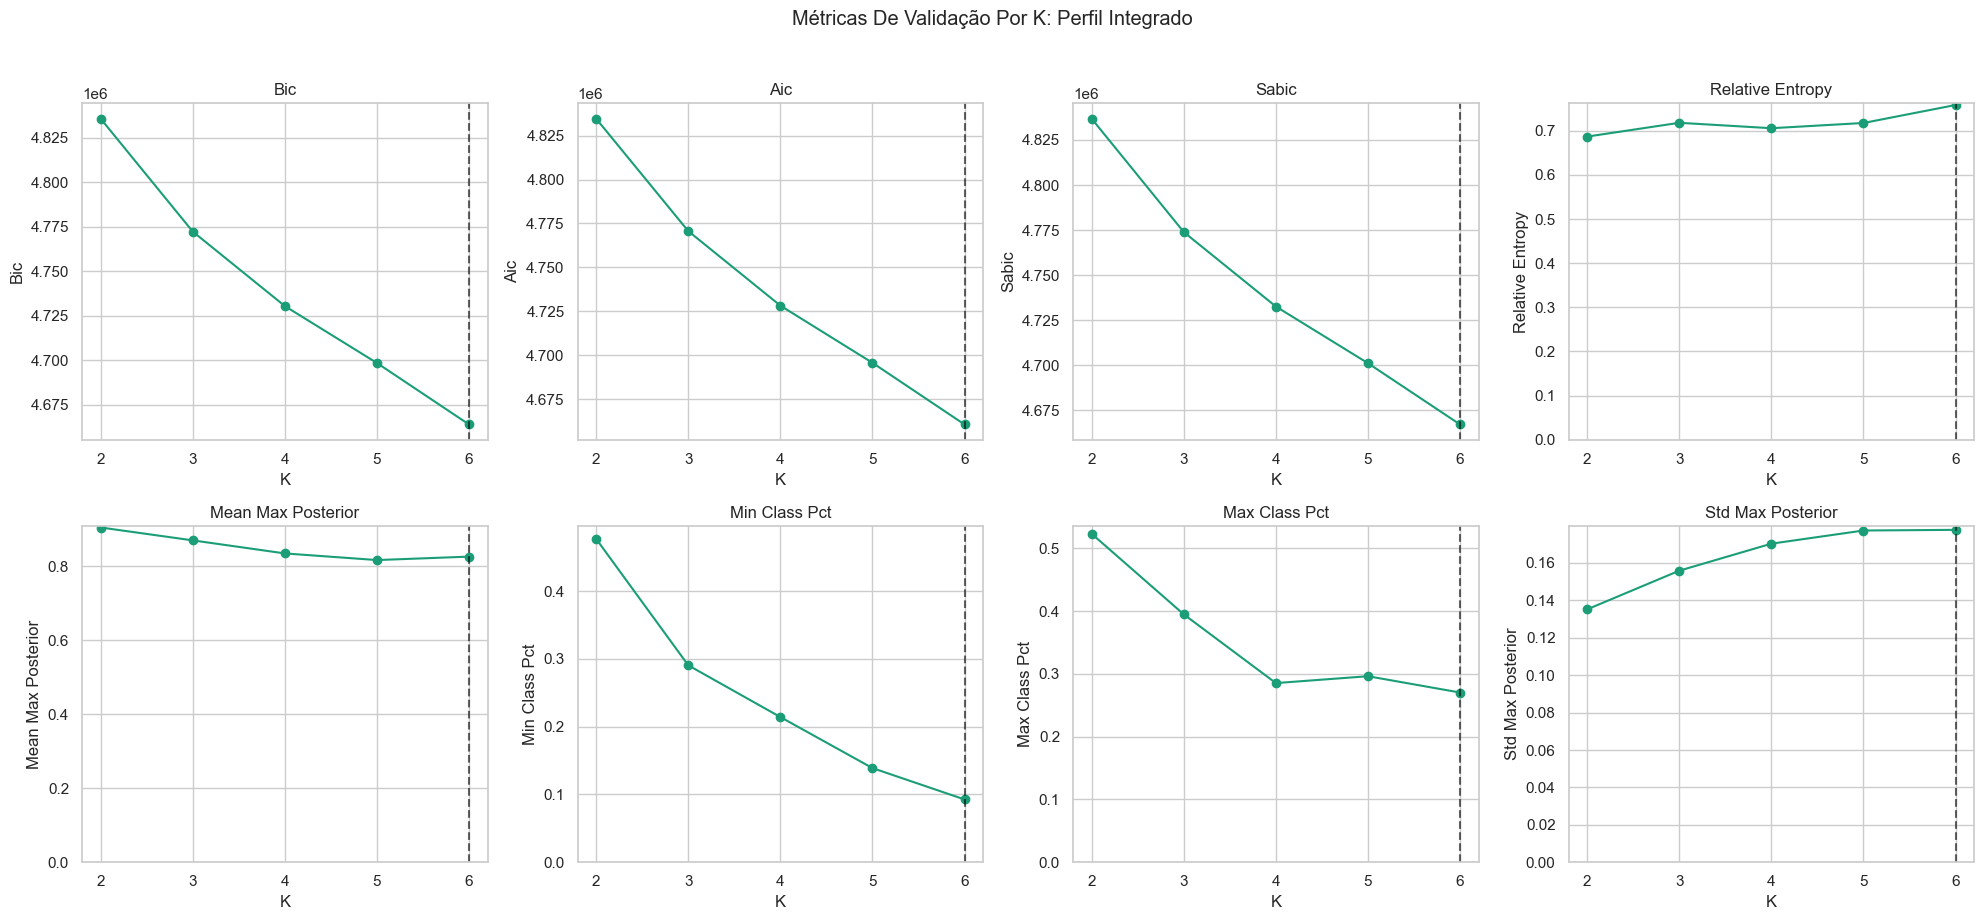

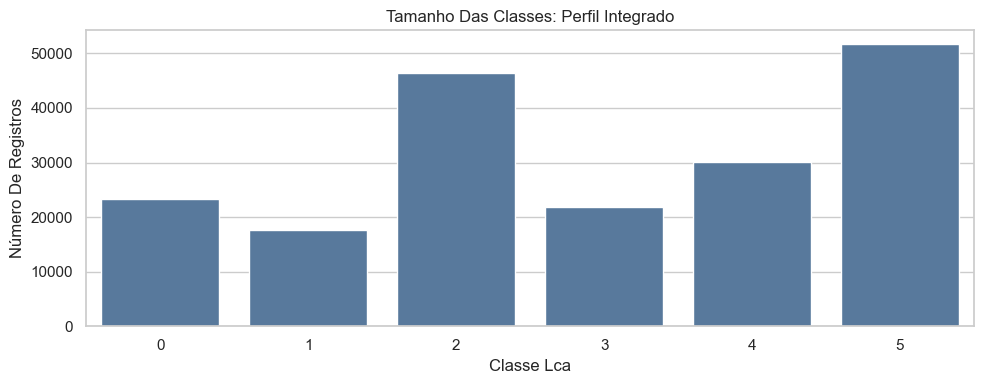

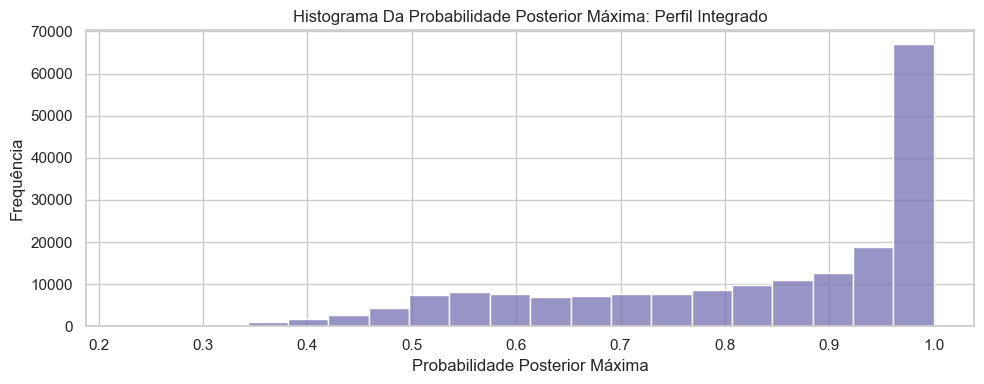

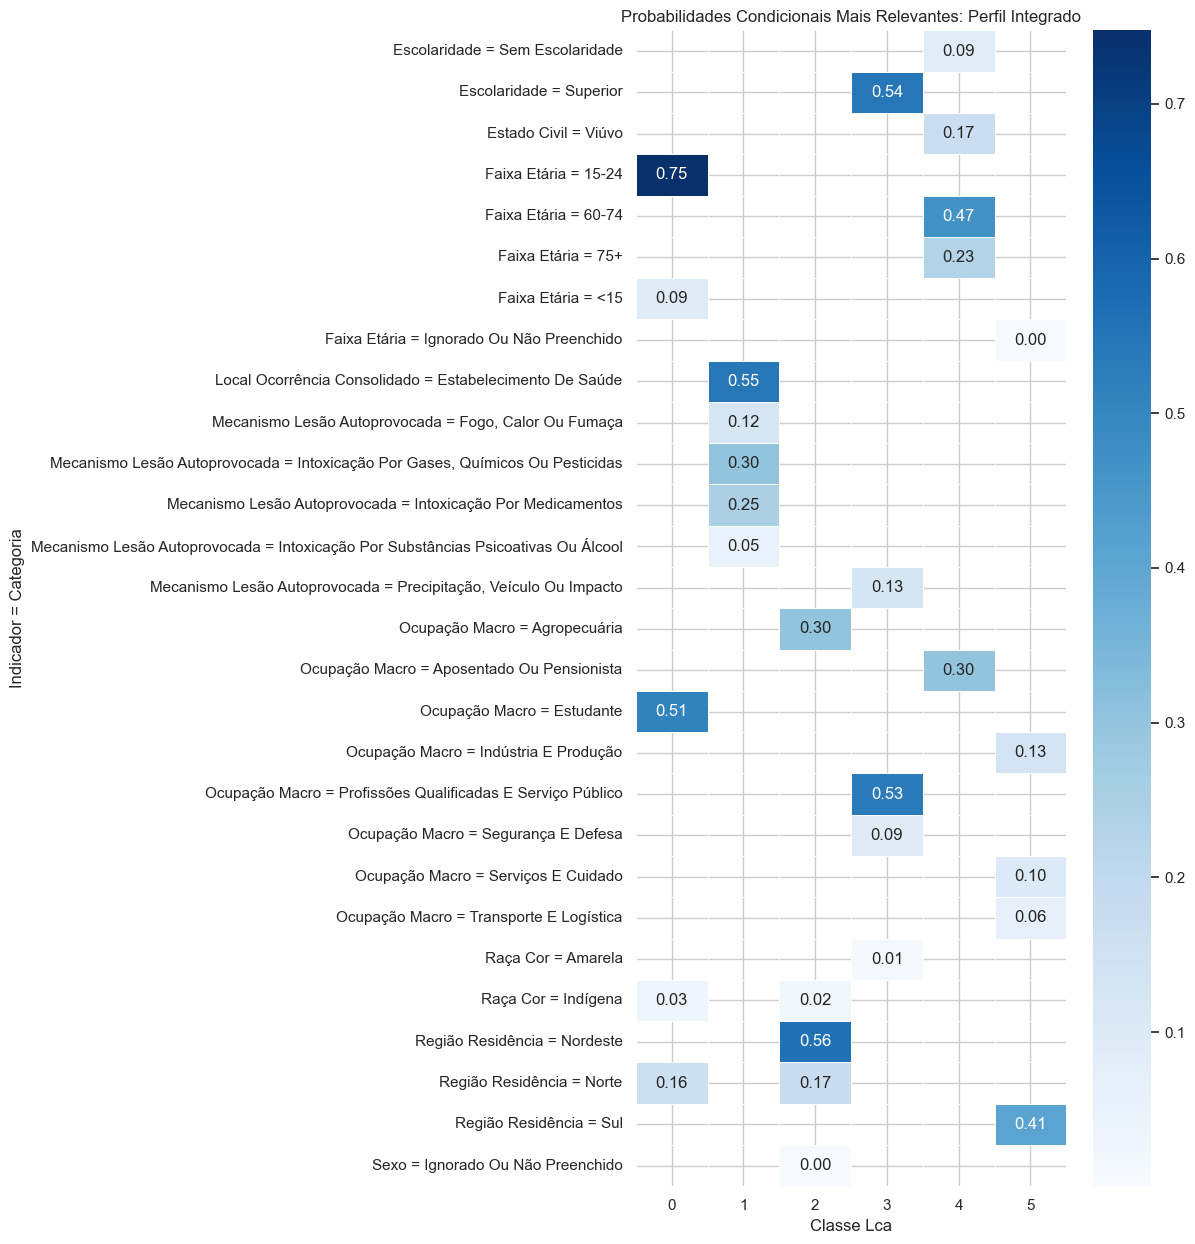

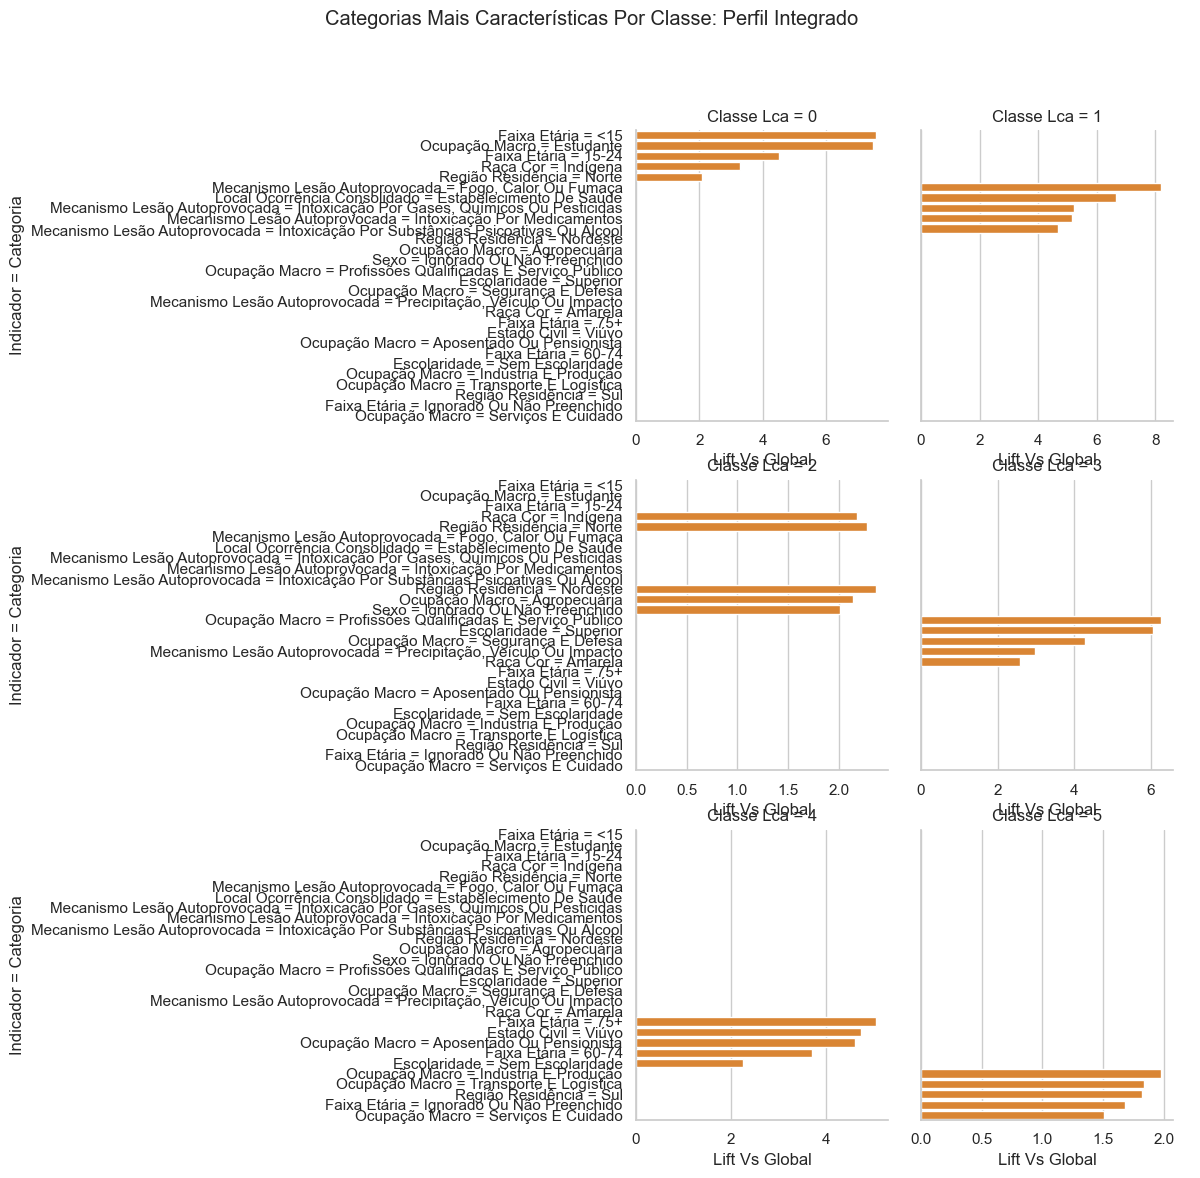

c:\Users\anami\Downloads\TCC Aninha\TCC_Aninha_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


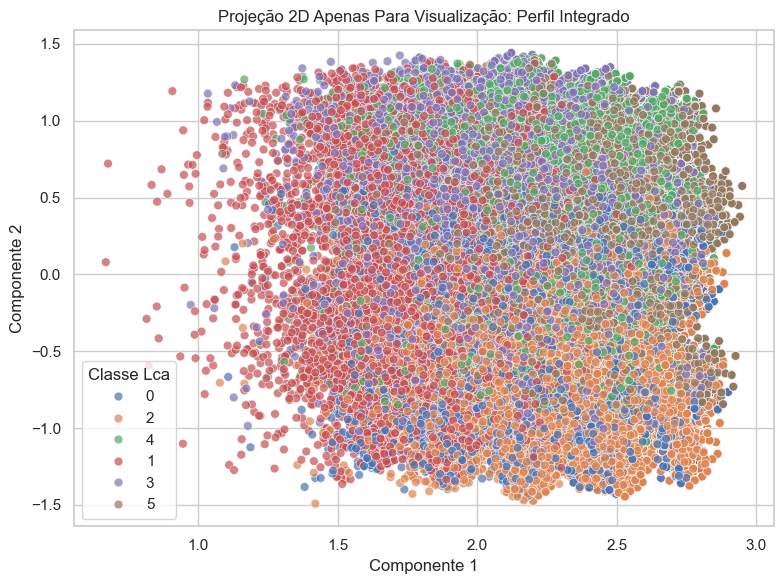

Melhor K em Perfil Integrado: 6
Ajuste Final Na Base Completa: True
Sem alertas adicionais para este perfil.


In [88]:
ResultadoPerfilIntegrado = ExecutarPerfilLca(
    'Perfil Integrado',
    BasePerfilIntegrado,
)

ExibirDiagnosticoPerfil(ResultadoPerfilIntegrado, 'Perfil Integrado')

,K,Bic,Aic,Sabic,Relative Entropy,Mean Max Posterior,Std Max Posterior,Min Class Pct,Max Class Pct,Classes Vazias,Converged,Número De Iterações,Número De Parâmetros,Tempo De Execução,Status Seleção,Warnings,Erro
0,2,4.835789e+06,4.834641e+06,4.836804e+06,0.686669,0.904697,0.135215,0.476901,0.523099,0,True,100,113,367.031771,Elegível,,
1,3,4.772372e+06,4.770645e+06,4.773899e+06,0.717911,0.869907,0.155889,0.290459,0.394828,0,True,168,170,728.937001,Elegível,,
2,4,4.730529e+06,4.728223e+06,4.732568e+06,0.705642,0.834628,0.170328,0.214145,0.285345,0,True,239,227,971.258894,Elegível,,
3,5,4.698551e+06,4.695665e+06,4.701102e+06,0.717493,0.816701,0.177371,0.138861,0.296281,0,True,198,284,993.545348,Elegível,,
4,6,4.664019e+06,4.660554e+06,4.667082e+06,0.758250,0.826000,0.177723,0.092611,0.270284,0,True,250,341,896.650156,Elegível,,


,Classe Lca,Prevalência Classe,Número De Registros,Probabilidade Posterior Média
0,0,0.129122,23401,0.851426
1,1,0.093699,17691,0.821101
2,2,0.244711,46352,0.844911
3,3,0.118748,21874,0.841216
4,4,0.163192,30076,0.850260
5,5,0.250528,51631,0.778600


,Classe Lca,Prevalência,Número De Registros,Posterior Média,Top Categorias Por Indicador,Nome Interpretativo Sugerido,Descrição Narrativa Curta
0,0,0.129122,23401,0.851426,"Deslocamento Geográfico: Outra Uf (Lift 1.10, Pct Condicional 0.01); Escolaridade: Médio (Lift 1.68, Pct Condicional 0.33); Estado Civil: Solteiro (Lift 1.8...",Feminino | <15 | Estudante,Classe marcada principalmente por Deslocamento Geográfico: Outra Uf; Escolaridade: Médio; Estado Civil: Solteiro; Faixa Etária: <15; Indício Transtorno Ment...
1,1,0.093699,17691,0.821101,"Deslocamento Geográfico: Outro Município Mesma Uf (Lift 3.27, Pct Condicional 0.36); Escolaridade: Ignorado Ou Não Preenchido (Lift 1.18, Pct Condicional 0....",Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Construção E Manutenção,Classe marcada principalmente por Deslocamento Geográfico: Outro Município Mesma Uf; Escolaridade: Ignorado Ou Não Preenchido; Estado Civil: Viúvo; Faixa Et...
2,2,0.244711,46352,0.844911,"Deslocamento Geográfico: Outra Uf (Lift 1.05, Pct Condicional 0.01); Escolaridade: Sem Escolaridade (Lift 1.98, Pct Condicional 0.08); Estado Civil: Ignorad...",Ignorado Ou Não Preenchido | Ignorado Ou Não Preenchido | Agropecuária,Classe marcada principalmente por Deslocamento Geográfico: Outra Uf; Escolaridade: Sem Escolaridade; Estado Civil: Ignorado Ou Não Preenchido; Faixa Etária:...
3,3,0.118748,21874,0.841216,"Deslocamento Geográfico: Outra Uf (Lift 1.63, Pct Condicional 0.02); Escolaridade: Superior (Lift 6.06, Pct Condicional 0.54); Estado Civil: Separado Ou Div...",Feminino | 35-44 | Profissões Qualificadas E Serviço Público,Classe marcada principalmente por Deslocamento Geográfico: Outra Uf; Escolaridade: Superior; Estado Civil: Separado Ou Divorciado; Faixa Etária: 35-44; Indí...
4,4,0.163192,30076,0.850260,"Deslocamento Geográfico: Mesmo Município (Lift 1.07, Pct Condicional 0.94); Escolaridade: Sem Escolaridade (Lift 2.27, Pct Condicional 0.09); Estado Civil: ...",Masculino | 75+ | Aposentado Ou Pensionista,Classe marcada principalmente por Deslocamento Geográfico: Mesmo Município; Escolaridade: Sem Escolaridade; Estado Civil: Viúvo; Faixa Etária: 75+; Indício ...
5,5,0.250528,51631,0.778600,"Deslocamento Geográfico: Mesmo Município (Lift 1.02, Pct Condicional 0.90); Escolaridade: Fundamental II (Lift 1.31, Pct Condicional 0.28); Estado Civil: Ig...",Masculino | Ignorado Ou Não Preenchido | Indústria E Produção,Classe marcada principalmente por Deslocamento Geográfico: Mesmo Município; Escolaridade: Fundamental II; Estado Civil: Ignorado Ou Não Preenchido; Faixa Et...


Shape Probabilidades Condicionais: (408, 8)
Colunas Probabilidades Condicionais: ['Classe Lca', 'Indicador', 'Código Categoria', 'Categoria', 'Probabilidade Condicional', 'N Global', 'Pct Global', 'Lift Vs Global']


,Classe Lca,Indicador,Código Categoria,Categoria,Probabilidade Condicional,N Global,Pct Global,Lift Vs Global
0,0,Sexo,0,Feminino,3.081365e-01,41177,0.215558,1.429482e+00
1,0,Sexo,1,Ignorado Ou Não Preenchido,1.000000e-15,33,0.000173,5.788636e-12
2,0,Sexo,2,Masculino,6.918635e-01,149815,0.784269,8.821761e-01
3,0,Faixa Etária,0,15-24,7.474534e-01,31670,0.165790,4.508440e+00
4,0,Faixa Etária,1,25-34,1.535212e-01,40469,0.211852,7.246628e-01
5,0,Faixa Etária,2,35-44,5.728918e-03,38476,0.201419,2.844284e-02
6,0,Faixa Etária,3,45-59,1.000000e-15,44915,0.235126,4.253034e-15
7,0,Faixa Etária,4,60-74,2.242837e-05,24021,0.125748,1.783598e-04
8,0,Faixa Etária,5,75+,3.727310e-05,8738,0.045743,8.148425e-04
9,0,Faixa Etária,6,<15,9.322977e-02,2351,0.012307,7.575167e+00


,Classe Lca,Indicador,Categoria,Probabilidade Condicional,Lift Vs Global
0,0,Indício Transtorno Por Substâncias,Não,0.986620,1.004306
1,0,Indício Transtorno Mental,Não,0.975488,1.009243
2,0,Estado Civil,Solteiro,0.960257,1.865996
3,0,Deslocamento Geográfico,Mesmo Município,0.891829,1.014565
4,0,Faixa Etária,15-24,0.747453,4.508440
5,1,Indício Transtorno Por Substâncias,Não,0.947270,0.964251
6,1,Indício Transtorno Mental,Não,0.904148,0.935434
7,1,Deslocamento Geográfico,Mesmo Município,0.619728,0.705016
8,1,Local Ocorrência Consolidado,Estabelecimento De Saúde,0.546053,6.673261
9,1,Sexo,Masculino,0.522474,0.666192


Linhas válidas para o gráfico de probabilidade condicional: 30
Linhas válidas para o gráfico de Lift Vs Global: 30


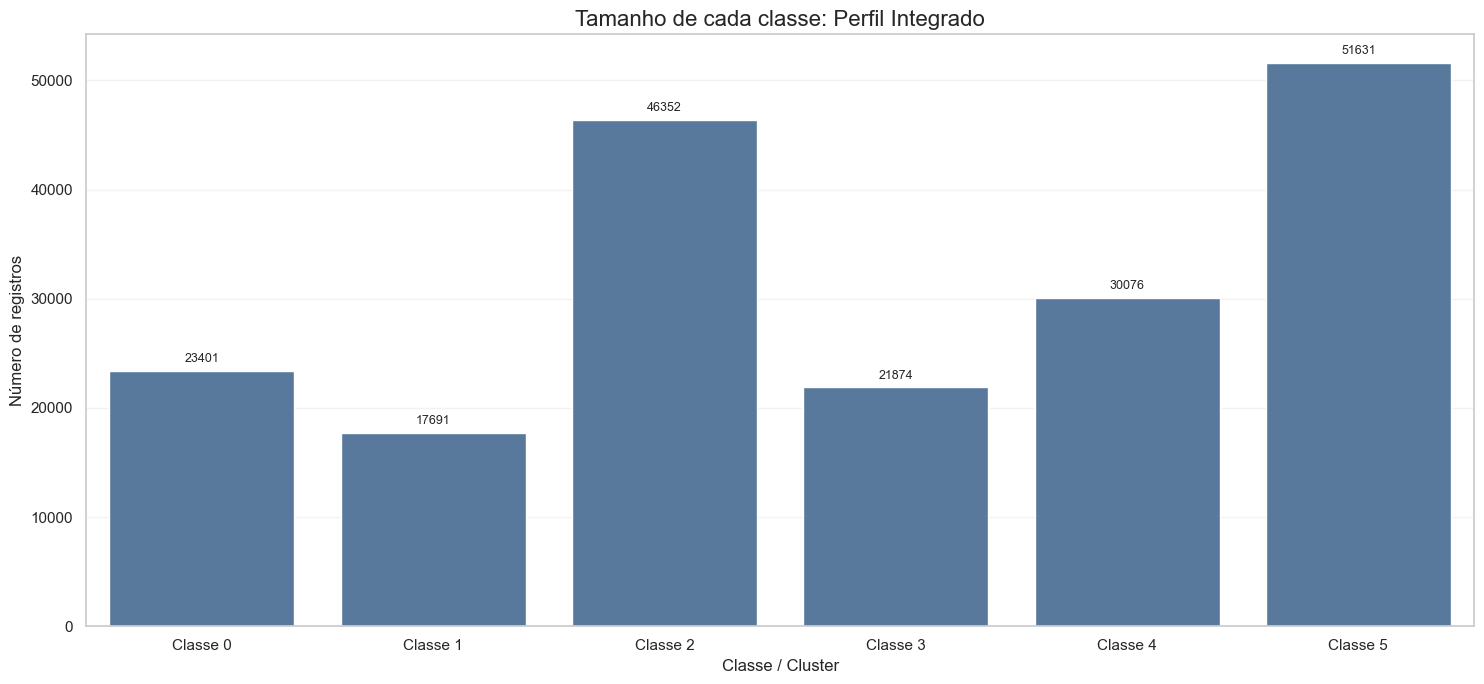

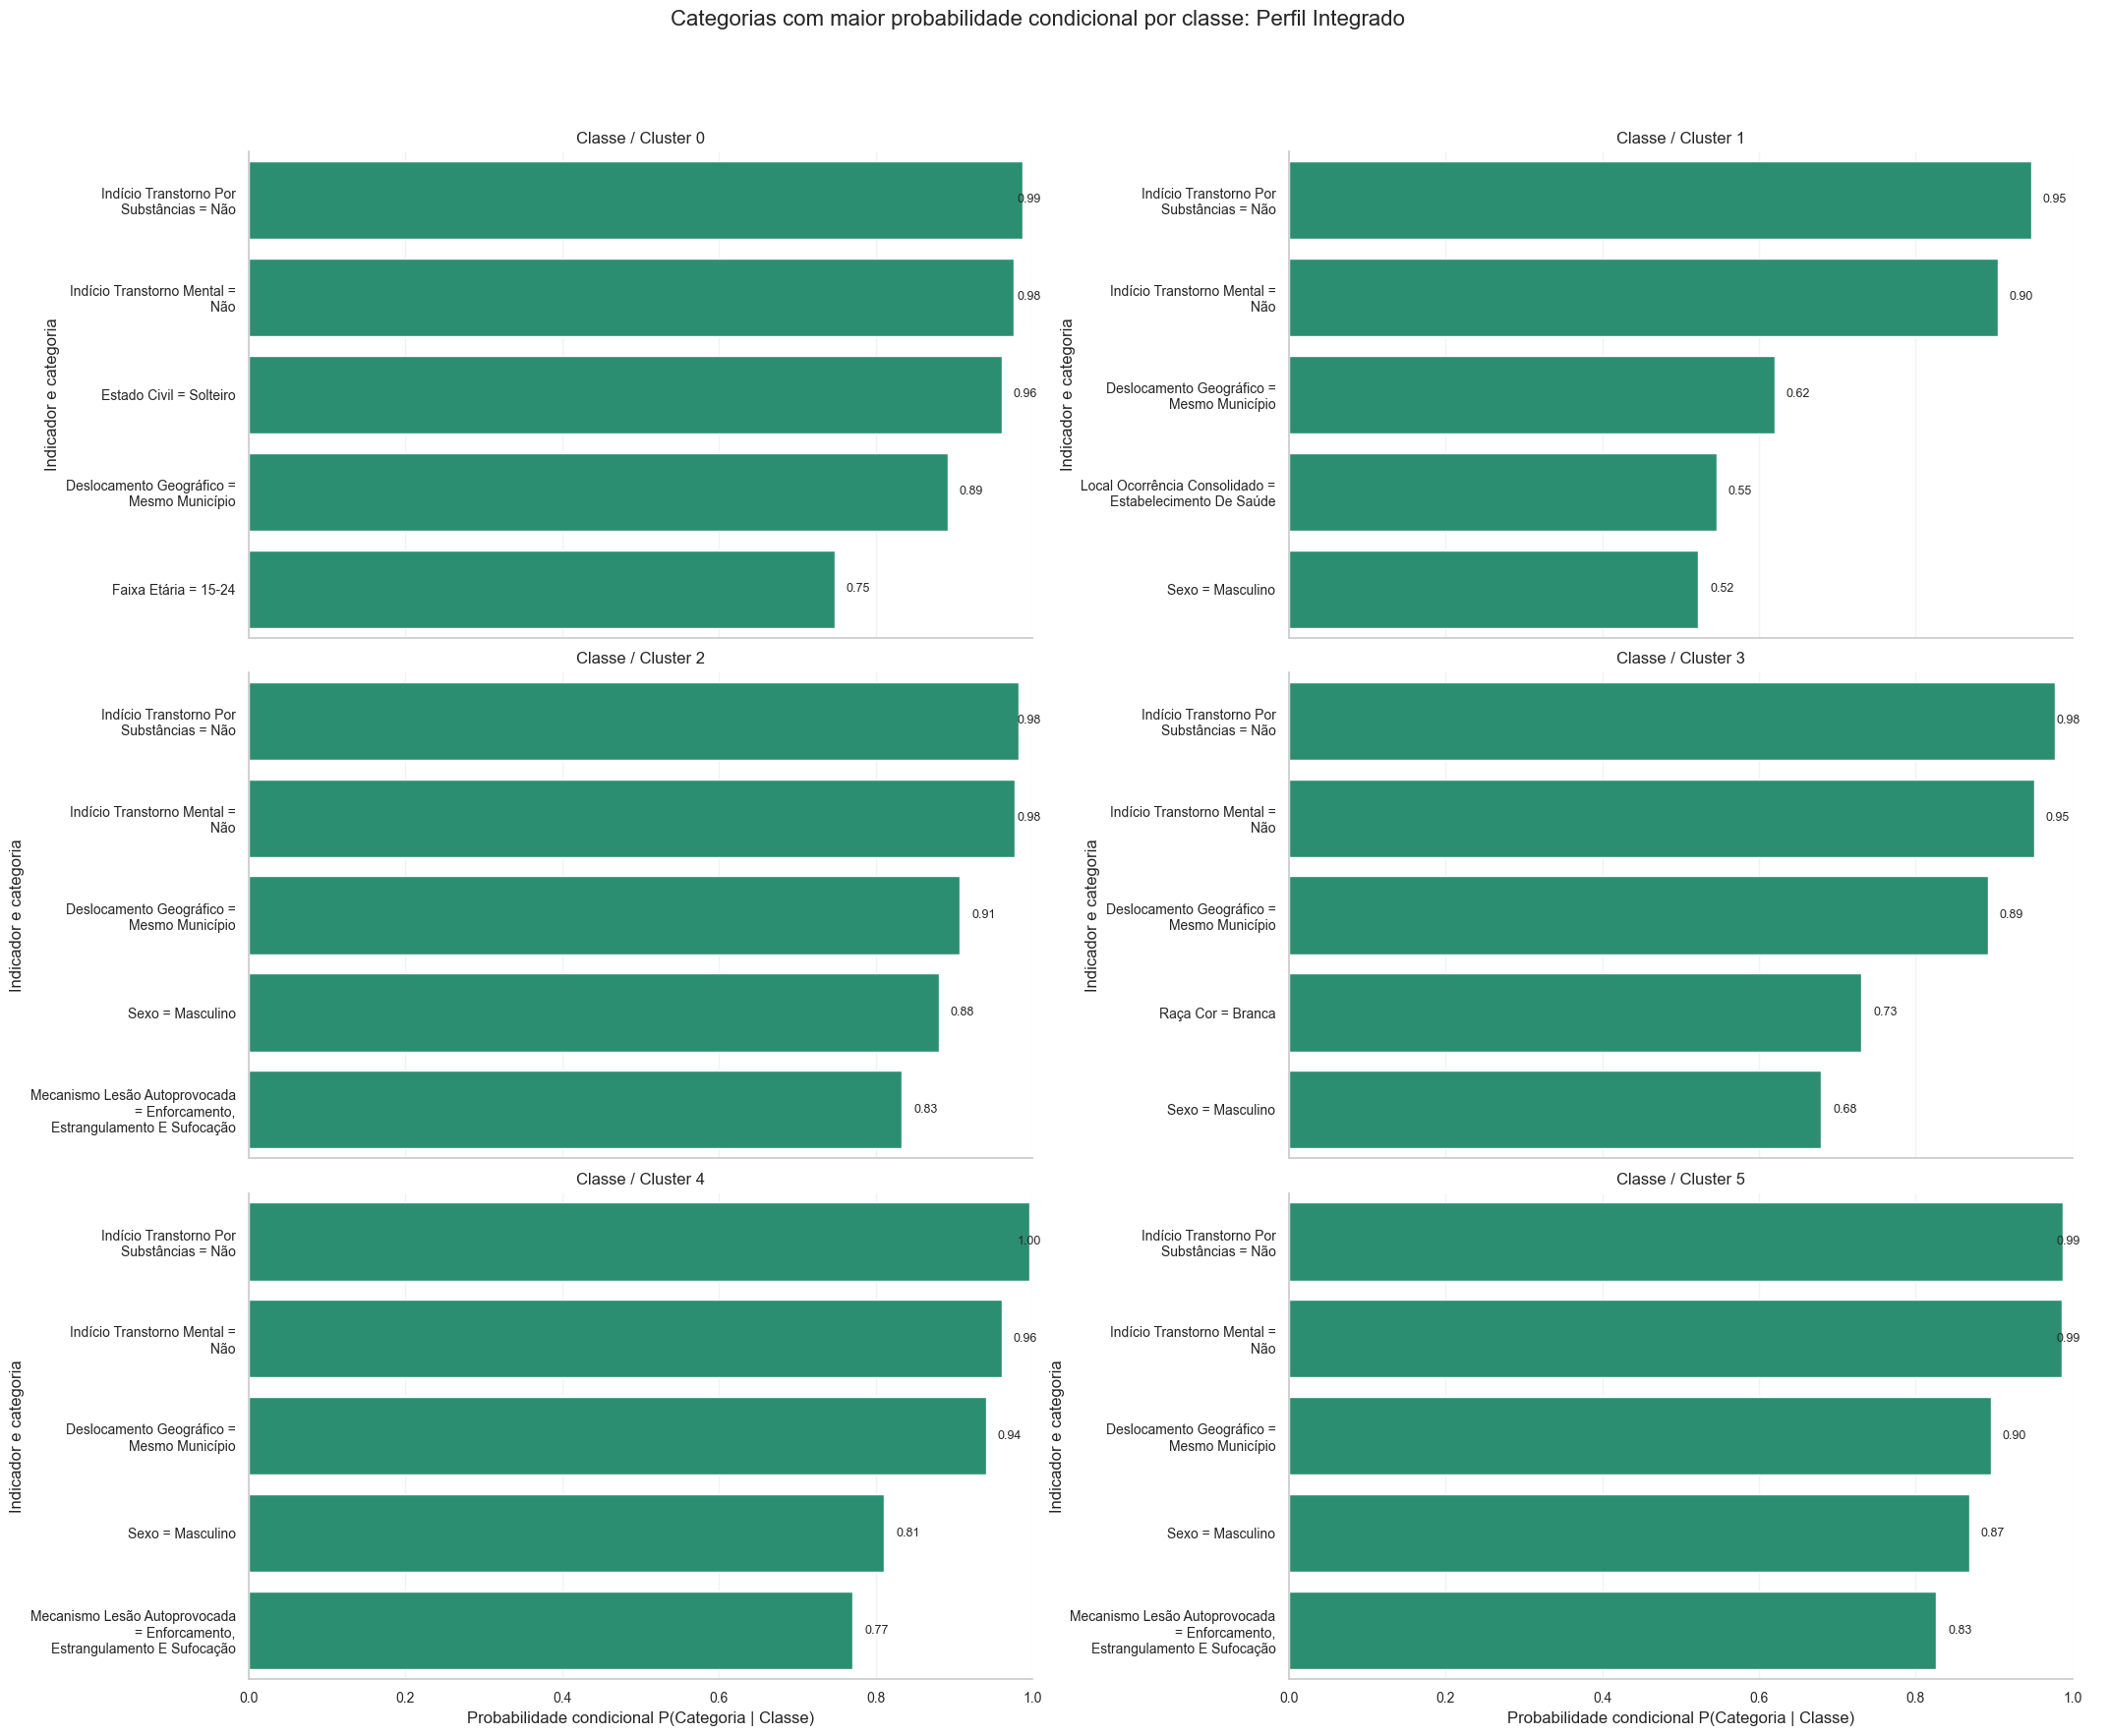

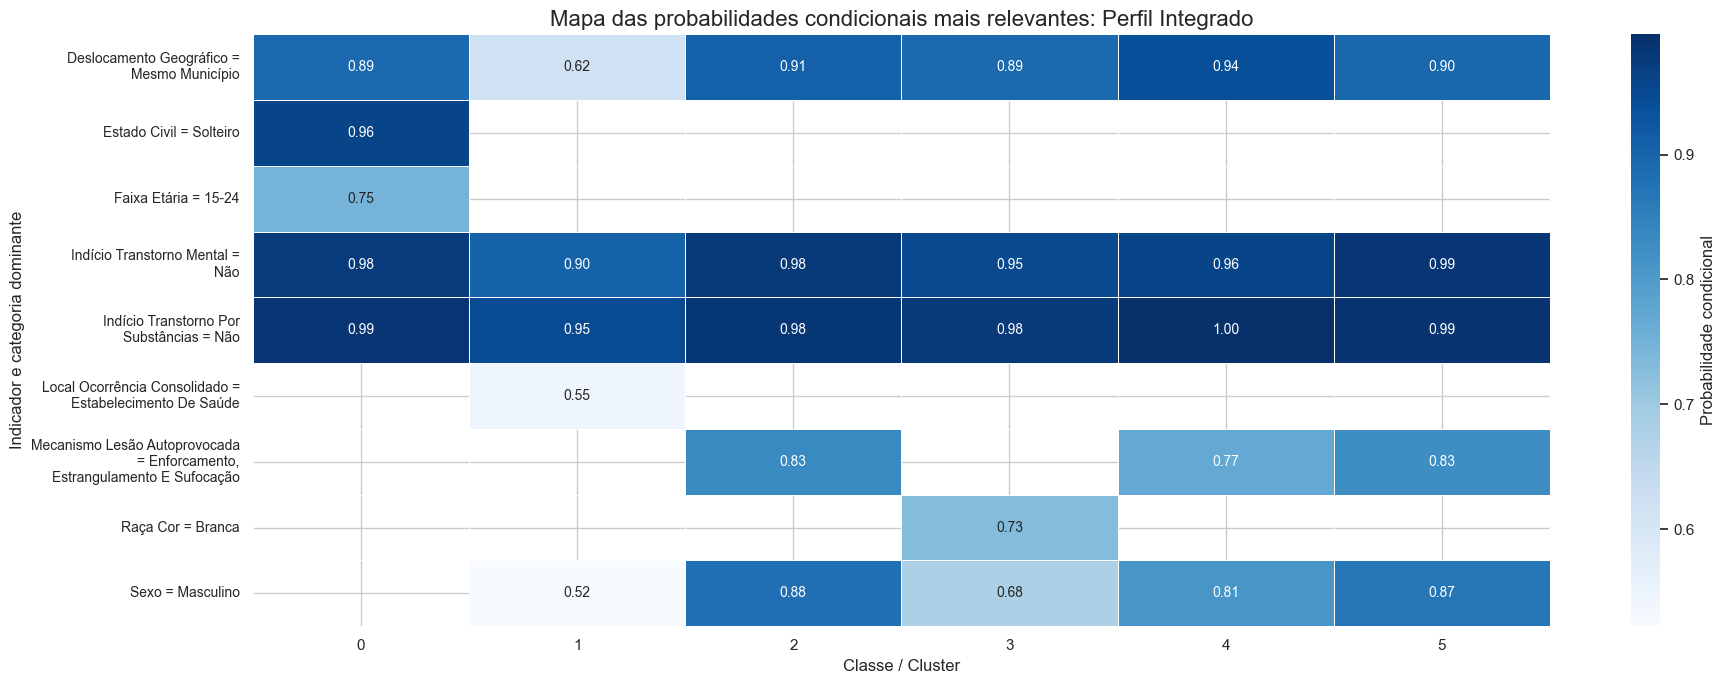

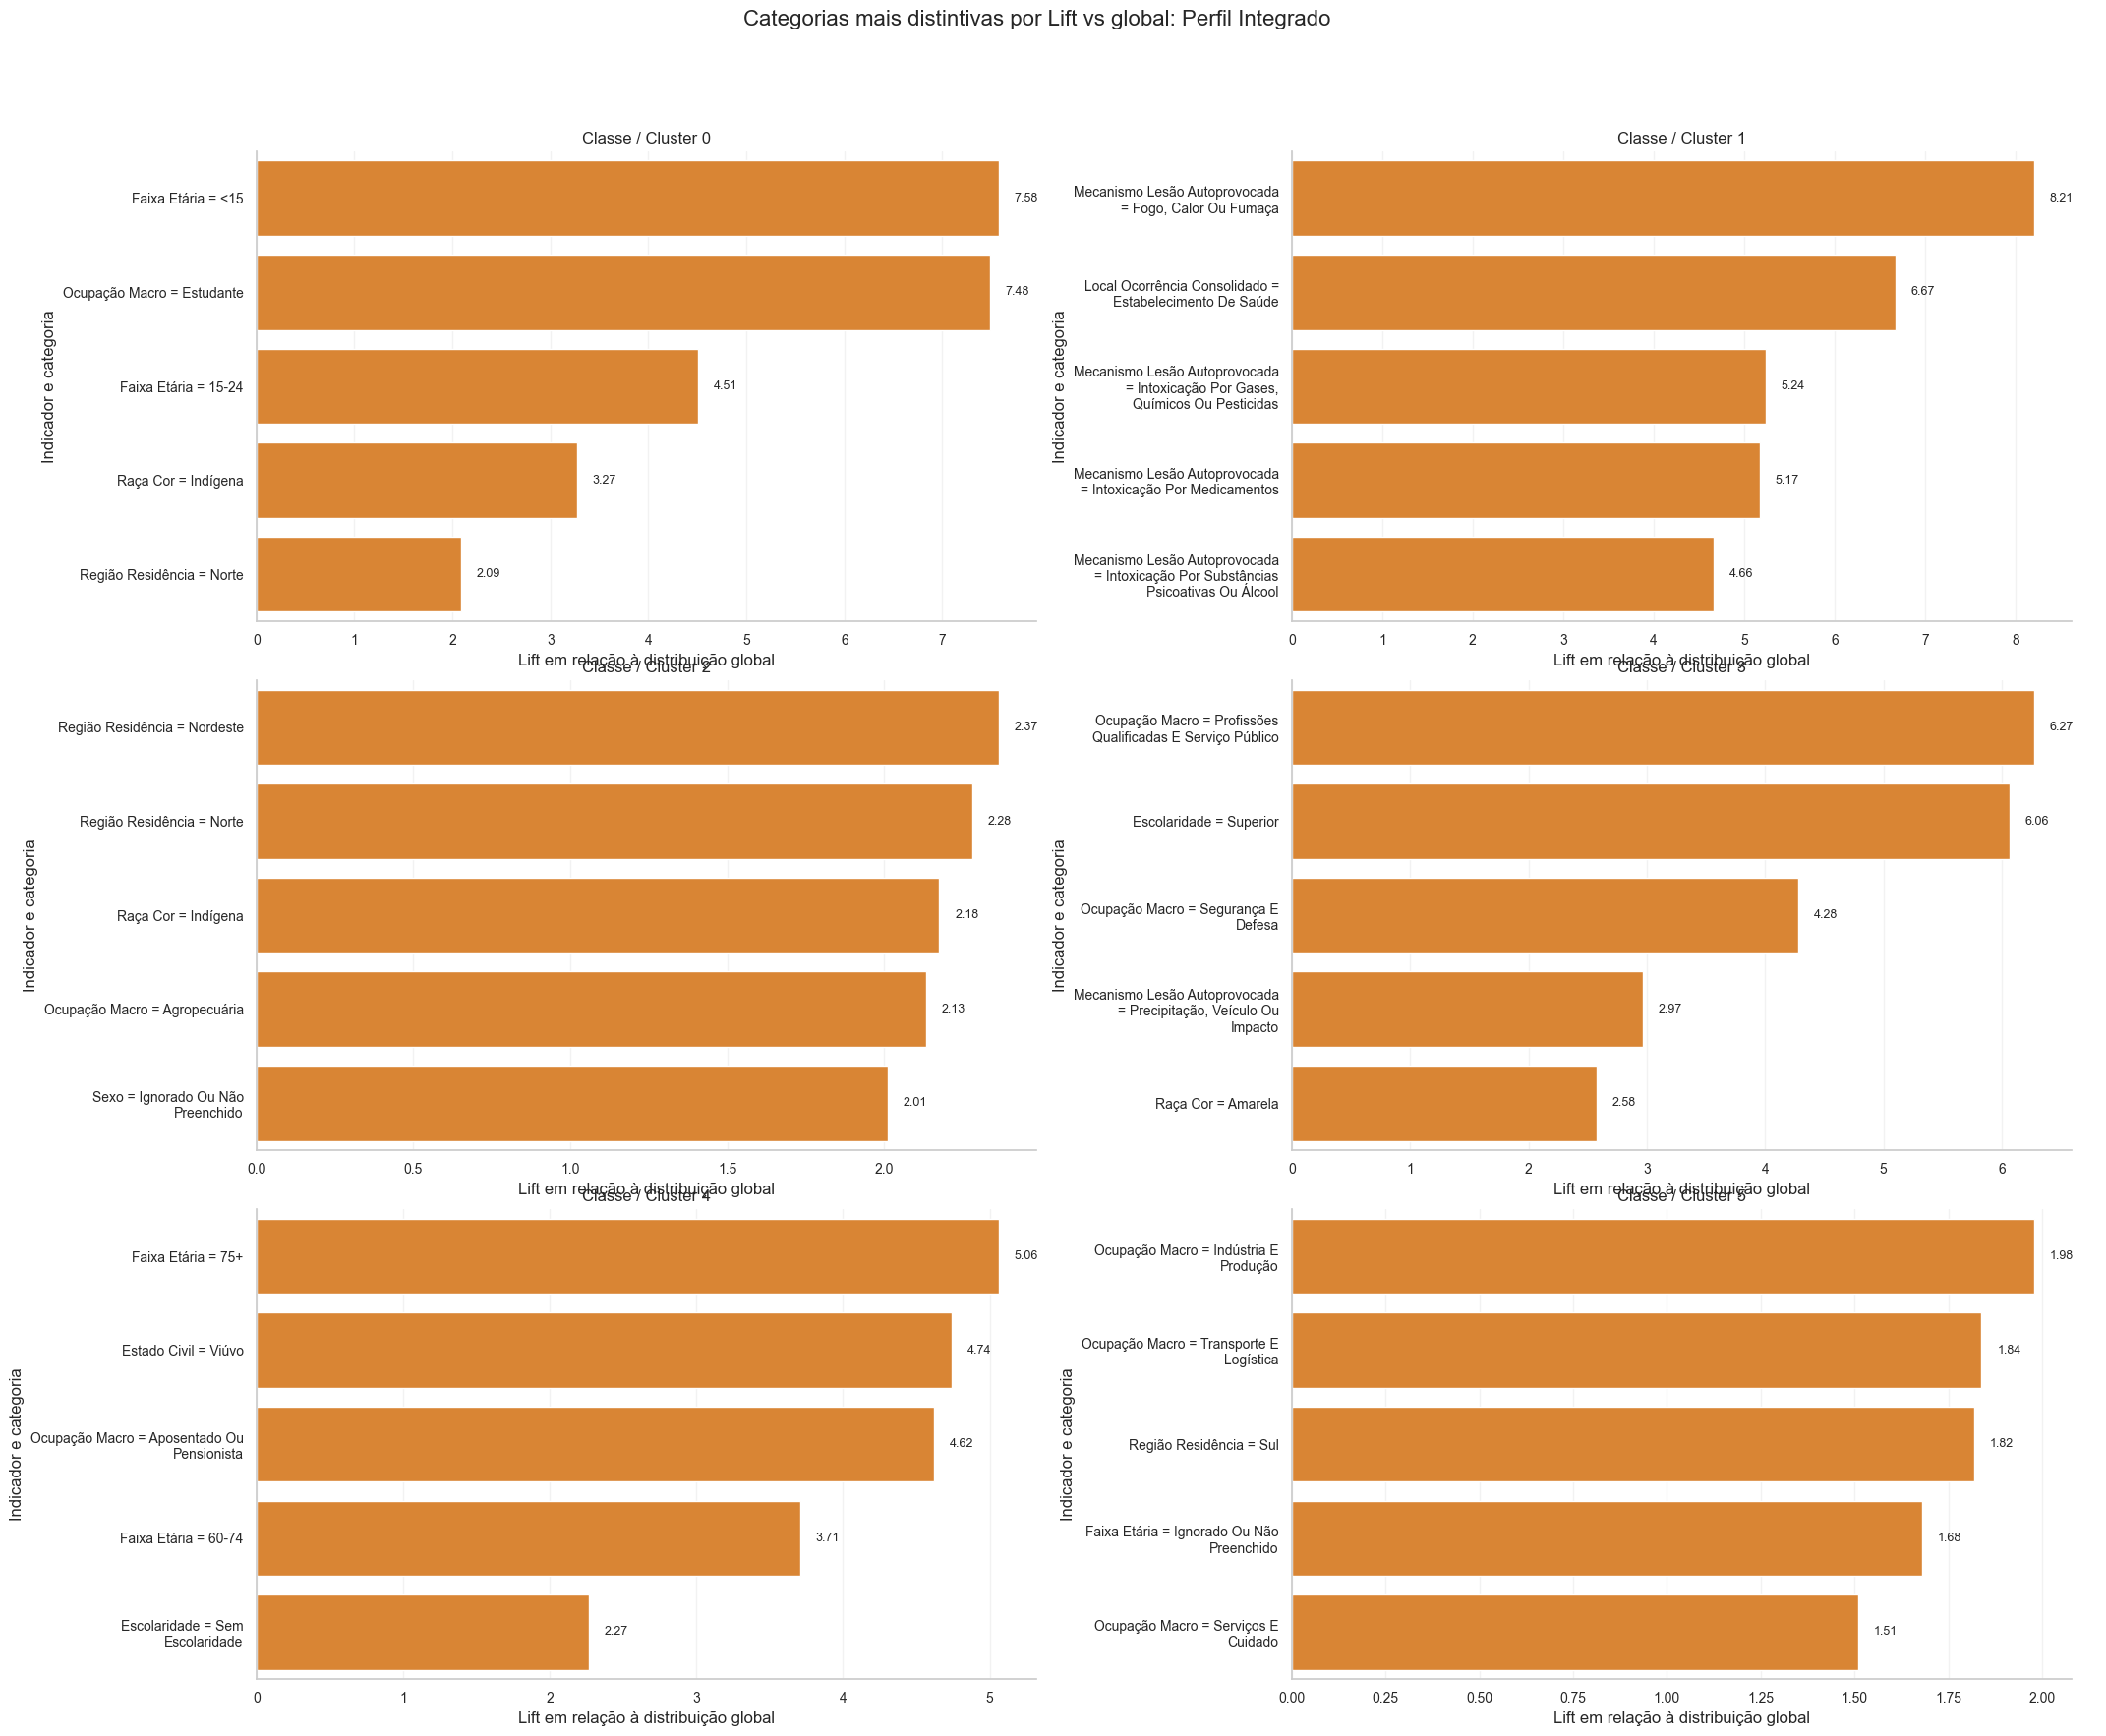

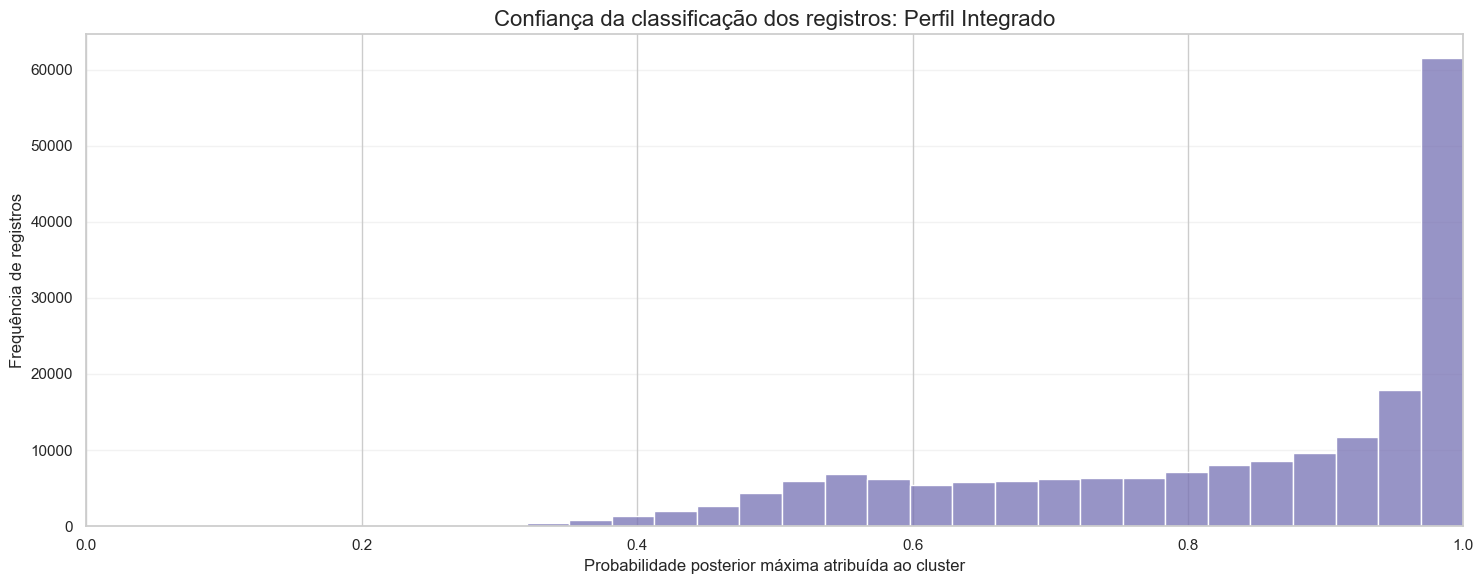

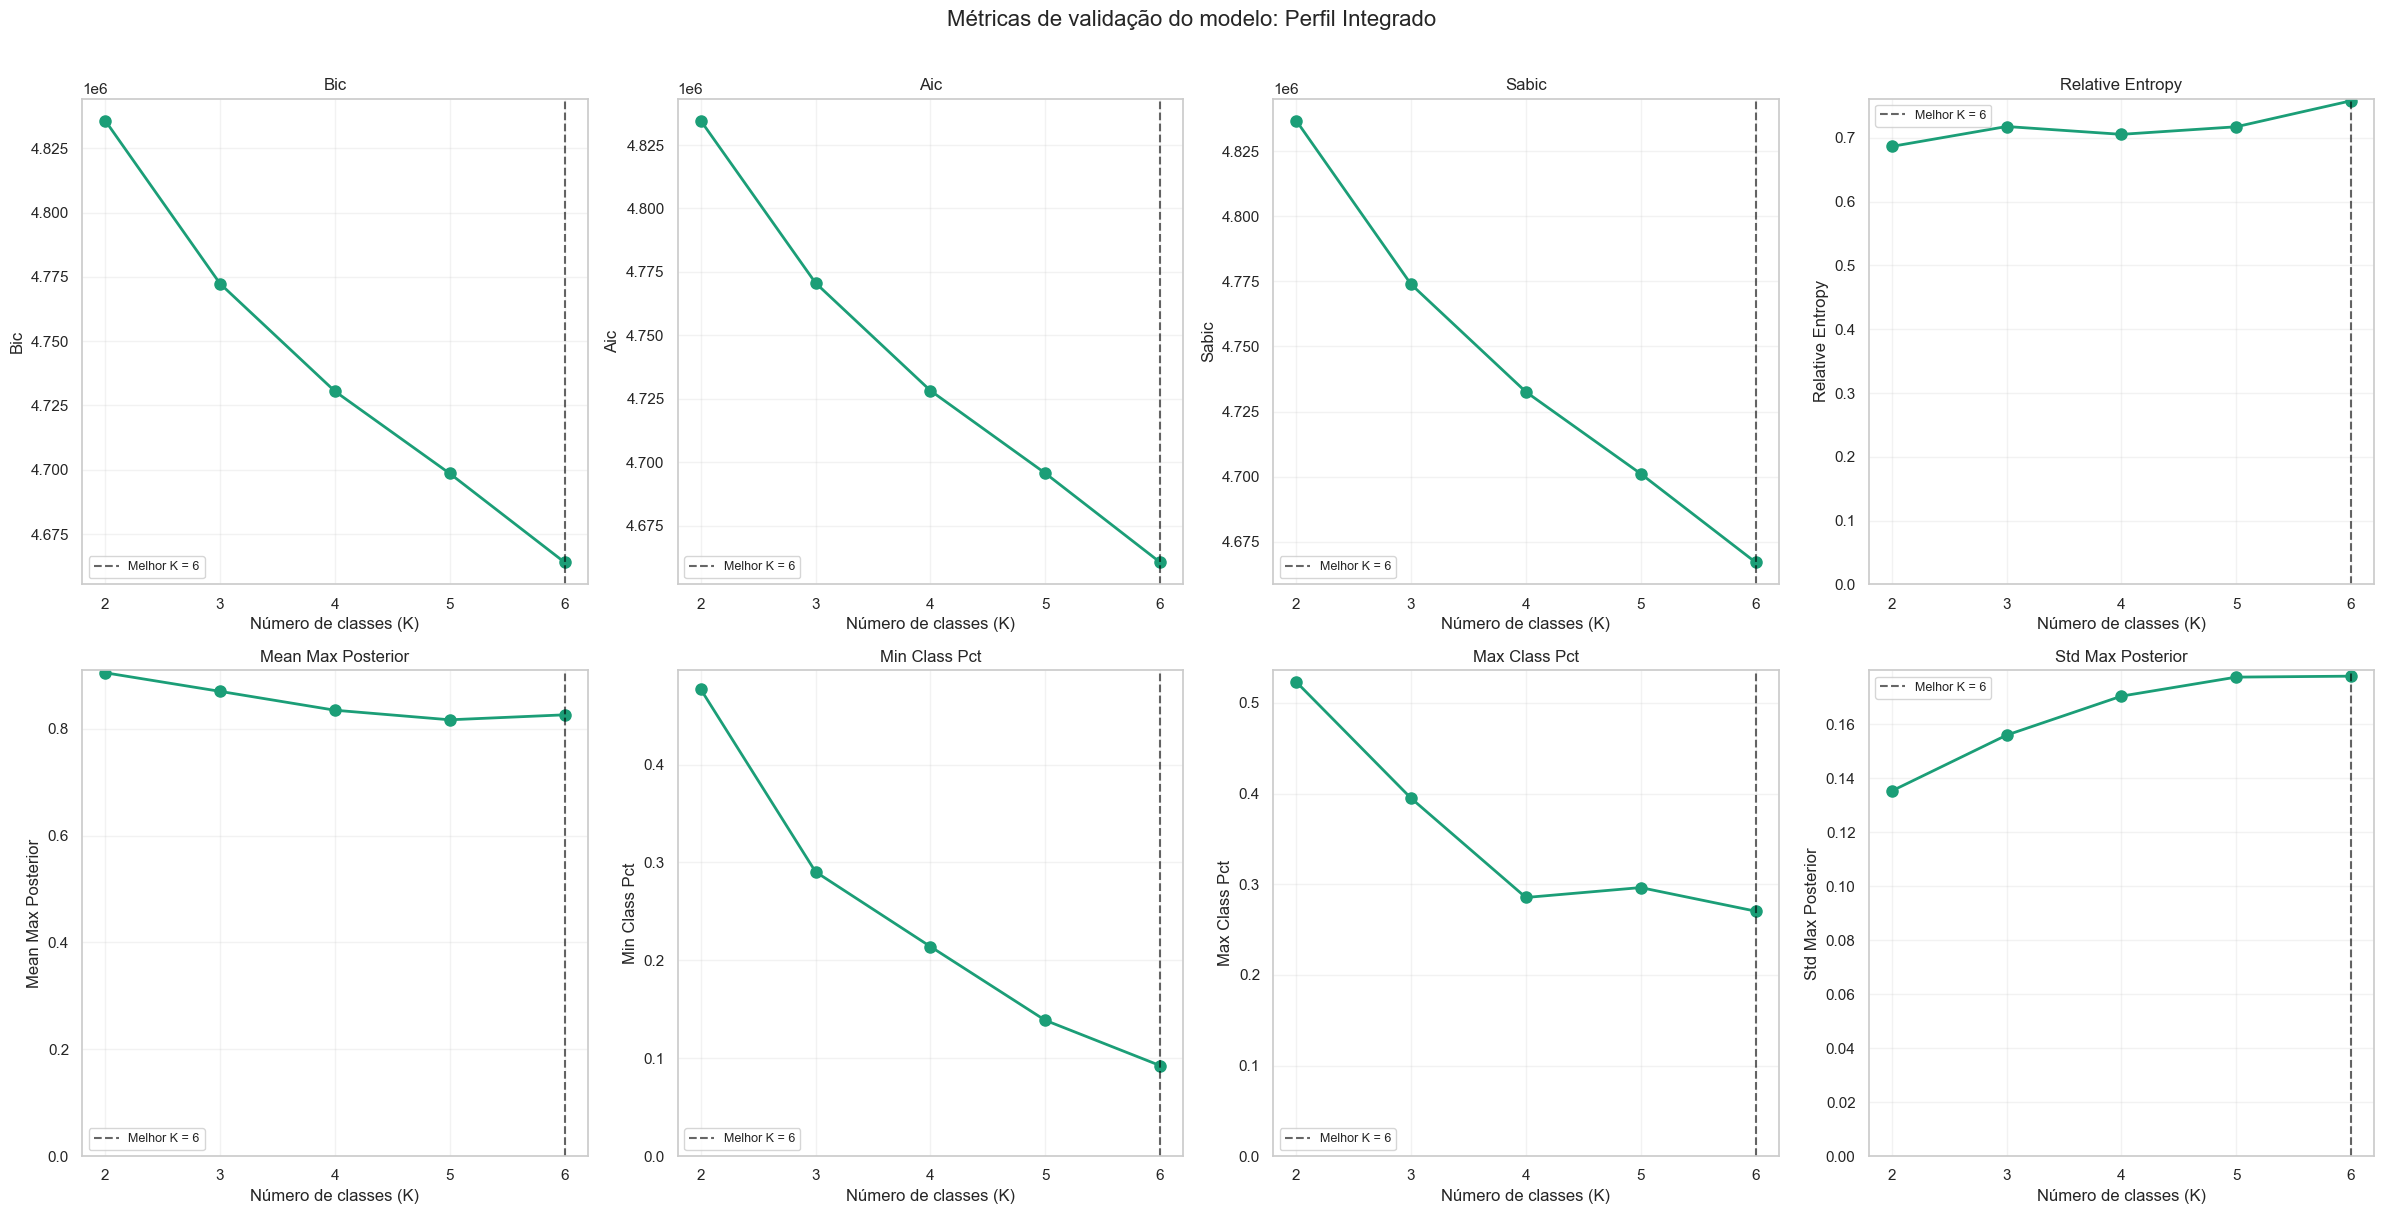

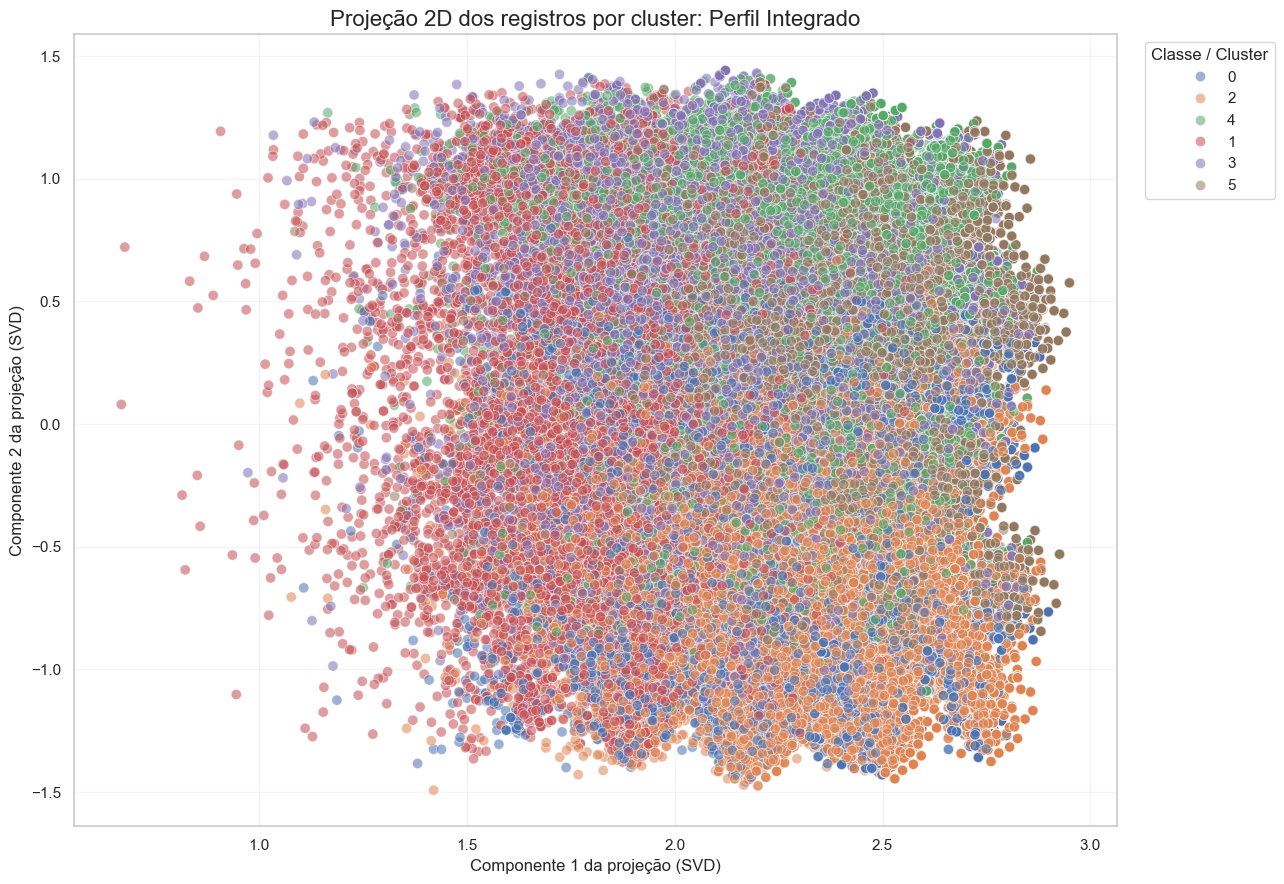

Melhor K em Perfil Integrado: 6
Ajuste Final Na Base Completa: True
Sem alertas adicionais para este perfil.


In [109]:
ExibirDiagnosticoPerfil(ResultadoPerfilIntegrado, 'Perfil Integrado')

## Resumo Final De Execução E Exportação Dos Arquivos

,Etapa,Tempo Segundos,Tempo Minutos
0,Carga Dos Insumos,0.238216,0.003970
1,Reconstrucao Da Base Limpa,1.542484,0.025708
2,Dicionario De Colunas,0.343979,0.005733
3,Lca Perfil Integrado,5002.258762,83.370979


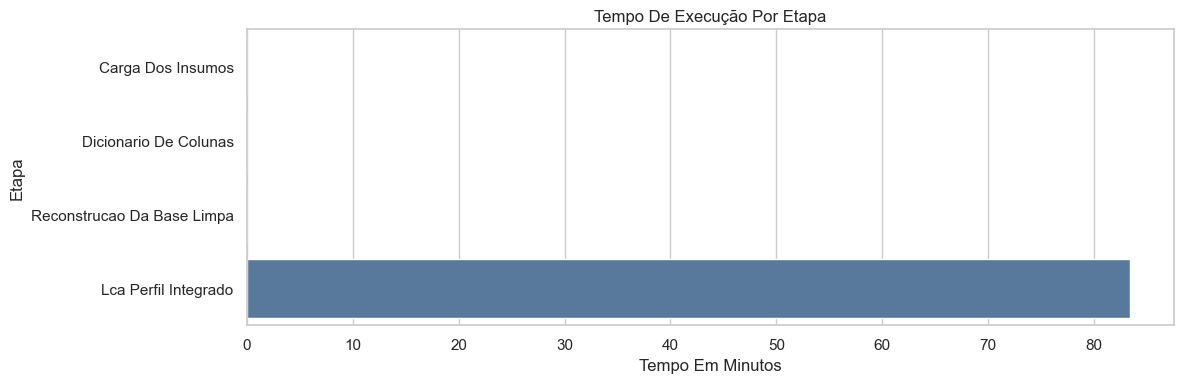

,Nome Arquivo,Caminho
0,Base Codificada Perfil Integrado.parquet,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Base Codificada Perfil Integrado.parquet
1,Base Com Classes Perfil Integrado.parquet,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Base Com Classes Perfil Integrado.parquet
2,Base Perfil Integrado.parquet,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Base Perfil Integrado.parquet
3,Dataset Limpo Com Nomes Intuitivos.parquet,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Dataset Limpo Com Nomes Intuitivos.parquet
4,Dicionario De Colunas.csv,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Dicionario De Colunas.csv
5,Encoders Perfil Integrado.json,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Encoders Perfil Integrado.json
6,Mapeamento Ocupacao Macro.csv,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Mapeamento Ocupacao Macro.csv
7,Metricas Grade Perfil Integrado.csv,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Metricas Grade Perfil Integrado.csv
8,Posteriores Perfil Integrado.parquet,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Posteriores Perfil Integrado.parquet
9,Probabilidades Condicionais Perfil Integrado.csv,C:\Users\anami\Downloads\TCC Aninha\outputs_lca\Probabilidades Condicionais Perfil Integrado.csv


{'Perfis Principais': ['Perfil Integrado'],
 'Colunas Perfil Integrado': ['Sexo',
  'Faixa Etária',
  'Raça Cor',
  'Estado Civil',
  'Escolaridade',
  'Ocupação Macro',
  'Região Residência',
  'Deslocamento Geográfico',
  'Local Ocorrência Consolidado',
  'Mecanismo Lesão Autoprovocada',
  'Indício Transtorno Mental',
  'Indício Transtorno Por Substâncias'],
 'Colunas Derivadas Principais': ['Faixa Etária',
  'Ocupação Macro',
  'Deslocamento Geográfico',
  'Local Ocorrência Consolidado',
  'Mecanismo Lesão Autoprovocada',
  'Indício Transtorno Mental',
  'Indício Transtorno Por Substâncias'],
 'Perfil Integrado': {'Melhor K': 6,
  'Ajuste Na Base Completa': True,
  'Linhas Ajuste Final': 191025,
  'Alertas': []},
 'Avisos Gerais': [],
 'Arquivos Salvos': {'Dataset Limpo Com Nomes Intuitivos.parquet': 'C:\\Users\\anami\\Downloads\\TCC Aninha\\outputs_lca\\Dataset Limpo Com Nomes Intuitivos.parquet',
  'Mapeamento Ocupacao Macro.csv': 'C:\\Users\\anami\\Downloads\\TCC Aninha\\outputs_

In [89]:
ResumoFinal = ConstruirResumoFinal(
    ResultadoPerfilIntegrado,
)

Pipeline.SalvarJson(Estado, ResumoFinal, 'Resumo Final Lca.json')
Pipeline.SalvarMarkdownTexto(Estado, ConstruirResumoMarkdown(ResumoFinal), 'Resumo Final Lca.md')

TabelaTempos = Pandas.DataFrame(Estado.Tempos)
TabelaArquivos = (
    Pandas.DataFrame(
        [{'Nome Arquivo': NomeArquivo, 'Caminho': Caminho} for NomeArquivo, Caminho in Estado.ArquivosSalvos.items()]
    )
    .sort_values('Nome Arquivo')
    .reset_index(drop=True)
)

Display(TabelaTempos)
PlotarTempoExecucao(TabelaTempos)
Display(TabelaArquivos)
ResumoFinal